<a href="https://colab.research.google.com/github/zairalaraib/kalshi-analysis/blob/main/BTC_SOL_ETH_XRP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Finding a Trading Edge Between Kalshi Crypto Markets

### BTC • ETH • SOL • XRP | 15-Minute Markets

**Goal:** Test whether these four Kalshi markets move together — and more importantly, whether one market tends to move **before** another.

We start with one 15-minute contract to understand correlation, covariance and lead-lag relationships, then expand the experiment to **19 consecutive windows (76 contracts total)** and simulate a trading strategy.

In [22]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries loaded.")

Libraries loaded.


In [23]:
markets = {
    "BTC": "KXBTC15M-26SEP190430",
    "ETH": "KXETH15M-26SEP190430",
    "SOL": "KXSOL15M-26SEP190430",
    "XRP": "KXXRP15M-26SEP190430"
}

markets

{'BTC': 'KXBTC15M-26SEP190430',
 'ETH': 'KXETH15M-26SEP190430',
 'SOL': 'KXSOL15M-26SEP190430',
 'XRP': 'KXXRP15M-26SEP190430'}

In [24]:
BASE_URL = "https://api.elections.kalshi.com/trade-api/v2"

# 15-minute window ending at 04:30 ET
start_ts = int(pd.Timestamp("2026-09-19 08:15:00", tz="UTC").timestamp())
end_ts   = int(pd.Timestamp("2026-09-19 08:30:00", tz="UTC").timestamp())

print("Start:", pd.to_datetime(start_ts, unit="s", utc=True))
print("End:  ", pd.to_datetime(end_ts, unit="s", utc=True))

Start: 2026-09-19 08:15:00+00:00
End:   2026-09-19 08:30:00+00:00


In [25]:
markets = {
    "BTC": ("KXBTC15M", "KXBTC15M-26SEP190415"),
    "ETH": ("KXETH15M", "KXETH15M-26SEP190415"),
    "SOL": ("KXSOL15M", "KXSOL15M-26SEP190415"),
    "XRP": ("KXXRP15M", "KXXRP15M-26SEP190415")
}

markets

{'BTC': ('KXBTC15M', 'KXBTC15M-26SEP190415'),
 'ETH': ('KXETH15M', 'KXETH15M-26SEP190415'),
 'SOL': ('KXSOL15M', 'KXSOL15M-26SEP190415'),
 'XRP': ('KXXRP15M', 'KXXRP15M-26SEP190415')}

In [26]:
start_ts = int(pd.Timestamp("2026-09-19 08:00:00", tz="UTC").timestamp())
end_ts   = int(pd.Timestamp("2026-09-19 08:15:00", tz="UTC").timestamp())

print("Start:", pd.to_datetime(start_ts, unit="s", utc=True))
print("End:  ", pd.to_datetime(end_ts, unit="s", utc=True))

Start: 2026-09-19 08:00:00+00:00
End:   2026-09-19 08:15:00+00:00


In [27]:
all_data = {}

for name, (series, ticker) in markets.items():

    url = f"{BASE_URL}/markets/candlesticks"

    params = {
        "series_ticker": series,
        "market_tickers": ticker,
        "start_ts": start_ts,
        "end_ts": end_ts,
        "period_interval": 1
    }

    r = requests.get(url, params=params)

    print(name, "Status:", r.status_code)

    if r.status_code == 200:
        all_data[name] = r.json()

BTC Status: 200
ETH Status: 200
SOL Status: 200
XRP Status: 200


In [28]:
url = f"{BASE_URL}/markets"

params = {
    "series_ticker": "KXBTC15M",
    "limit": 100
}

r = requests.get(url, params=params)

print("Status:", r.status_code)

data = r.json()

print("Number returned:", len(data.get("markets", [])))

for m in data.get("markets", [])[:20]:
    print(m.get("ticker"), "|", m.get("close_time"))

Status: 200
Number returned: 100
KXBTC15M-26SEP200000-00 | 2026-09-20T04:00:00Z
KXBTC15M-26SEP192345-45 | 2026-09-20T03:45:00Z
KXBTC15M-26SEP192330-30 | 2026-09-20T03:30:00Z
KXBTC15M-26SEP192315-15 | 2026-09-20T03:15:00Z
KXBTC15M-26SEP192300-00 | 2026-09-20T03:00:00Z
KXBTC15M-26SEP192245-45 | 2026-09-20T02:45:00Z
KXBTC15M-26SEP192230-30 | 2026-09-20T02:30:00Z
KXBTC15M-26SEP192215-15 | 2026-09-20T02:15:00Z
KXBTC15M-26SEP192200-00 | 2026-09-20T02:00:00Z
KXBTC15M-26SEP192145-45 | 2026-09-20T01:45:00Z
KXBTC15M-26SEP192130-30 | 2026-09-20T01:30:00Z
KXBTC15M-26SEP192115-15 | 2026-09-20T01:15:00Z
KXBTC15M-26SEP192100-00 | 2026-09-20T01:00:00Z
KXBTC15M-26SEP192045-45 | 2026-09-20T00:45:00Z
KXBTC15M-26SEP192030-30 | 2026-09-20T00:30:00Z
KXBTC15M-26SEP192015-15 | 2026-09-20T00:15:00Z
KXBTC15M-26SEP192000-00 | 2026-09-20T00:00:00Z
KXBTC15M-26SEP191945-45 | 2026-09-19T23:45:00Z
KXBTC15M-26SEP191930-30 | 2026-09-19T23:30:00Z
KXBTC15M-26SEP191915-15 | 2026-09-19T23:15:00Z


In [29]:
markets = {
    "BTC": ("KXBTC15M", "KXBTC15M-26SEP190415-15"),
    "ETH": ("KXETH15M", "KXETH15M-26SEP190415-15"),
    "SOL": ("KXSOL15M", "KXSOL15M-26SEP190415-15"),
    "XRP": ("KXXRP15M", "KXXRP15M-26SEP190415-15")
}

for name, (series, ticker) in markets.items():
    print(name, ticker)

BTC KXBTC15M-26SEP190415-15
ETH KXETH15M-26SEP190415-15
SOL KXSOL15M-26SEP190415-15
XRP KXXRP15M-26SEP190415-15


In [30]:
all_data = {}

for name, (series, ticker) in markets.items():

    url = f"{BASE_URL}/markets/candlesticks"

    params = {
        "series_ticker": series,
        "market_tickers": ticker,
        "start_ts": start_ts,
        "end_ts": end_ts,
        "period_interval": 1
    }

    r = requests.get(url, params=params)

    if r.status_code == 200:
        data = r.json()
        all_data[name] = data

        print(
            name,
            "| status:", r.status_code,
            "| markets:", len(data.get("markets", []))
        )
    else:
        print(name, "| ERROR:", r.status_code, r.text[:200])

BTC | status: 200 | markets: 1
ETH | status: 200 | markets: 1
SOL | status: 200 | markets: 1
XRP | status: 200 | markets: 1


In [31]:
btc_market = all_data["BTC"]["markets"][0]

print(btc_market.keys())
print()
print("Number of candles:", len(btc_market["candlesticks"]))
print()
print(btc_market["candlesticks"][0])

dict_keys(['candlesticks', 'market_ticker'])

Number of candles: 15

{'end_period_ts': 1789804860, 'open_interest_fp': '45473.56', 'price': {'close_dollars': '0.4600', 'high_dollars': '0.5800', 'low_dollars': '0.4400', 'mean_dollars': '0.5182', 'open_dollars': '0.4400'}, 'volume_fp': '85815.03', 'yes_ask': {'close_dollars': '0.4600', 'high_dollars': '0.6600', 'low_dollars': '0.4400', 'open_dollars': '0.6600'}, 'yes_bid': {'close_dollars': '0.4500', 'high_dollars': '0.5700', 'low_dollars': '0.0000', 'open_dollars': '0.0000'}}


## 1. Building the Market Prices

For each market, I calculate the **YES mid-price**:

**YES Mid = (YES Bid + YES Ask) / 2**

This gives a single estimate of the market's current probability while avoiding relying only on either the bid or ask.

In [32]:
frames = []

for name in ["BTC", "ETH", "SOL", "XRP"]:

    candles = all_data[name]["markets"][0]["candlesticks"]

    rows = []

    for c in candles:
        yes_bid = float(c["yes_bid"]["close_dollars"])
        yes_ask = float(c["yes_ask"]["close_dollars"])

        rows.append({
            "timestamp": pd.to_datetime(
                c["end_period_ts"],
                unit="s",
                utc=True
            ),
            name: (yes_bid + yes_ask) / 2
        })

    frames.append(pd.DataFrame(rows).set_index("timestamp"))

prices = pd.concat(frames, axis=1).sort_index()

prices

,BTC,ETH,SOL,XRP
timestamp,,,,
2026-09-19 08:01:00+00:00,0.4550,0.3850,0.4350,0.4050
2026-09-19 08:02:00+00:00,0.3250,0.2350,0.3850,0.3950
2026-09-19 08:03:00+00:00,0.3250,0.2550,0.5050,0.5200
2026-09-19 08:04:00+00:00,0.2750,0.2550,0.5050,0.5150
2026-09-19 08:05:00+00:00,0.3950,0.3950,0.6400,0.6550
2026-09-19 08:06:00+00:00,0.2950,0.2850,0.6350,0.6750
2026-09-19 08:07:00+00:00,0.3050,0.3850,0.8050,0.7350
2026-09-19 08:08:00+00:00,0.7450,0.8350,0.9040,0.8800
2026-09-19 08:09:00+00:00,0.8750,0.9190,0.9350,0.8750


## 2. Do These Crypto Markets Move Together?

First, I tested a single 15-minute window.

The correlation matrix compares the **YES probability levels** of BTC, ETH, SOL and XRP.

A correlation close to **+1** means two markets tended to move together, while a value close to **0** means little linear relationship.

In [33]:
correlation = prices.corr()

print("CORRELATION MATRIX")
display(correlation.round(4))

CORRELATION MATRIX


,BTC,ETH,SOL,XRP
BTC,1.0000,0.9902,0.8903,0.8904
ETH,0.9902,1.0000,0.9367,0.9298
SOL,0.8903,0.9367,1.0000,0.9923
XRP,0.8904,0.9298,0.9923,1.0000


### Insight

The correlations were extremely high.

- BTC ↔ ETH: **0.9902**
- SOL ↔ XRP: **0.9923**
- ETH ↔ SOL: **0.9367**

At first glance, it looks like these Kalshi crypto markets move almost perfectly together.

But there is a problem: these are **price levels** inside contracts that eventually converge toward 0 or 1.

So instead of only comparing their levels, I also need to compare their **minute-to-minute changes**.

In [34]:
covariance = prices.cov()

print("COVARIANCE MATRIX")
display(covariance.round(6))

COVARIANCE MATRIX


,BTC,ETH,SOL,XRP
BTC,0.100231,0.106711,0.066244,0.063157
ETH,0.106711,0.115877,0.074941,0.070909
SOL,0.066244,0.074941,0.055235,0.052250
XRP,0.063157,0.070909,0.052250,0.050195


## 3. Looking at Changes Instead of Levels

Rather than asking:

> "Are BTC and ETH priced similarly?"

I now ask:

> "When BTC's probability changes during one minute, does ETH's probability change during that same minute?"

For each market:

**Change = Current YES Mid − Previous Minute YES Mid**

In [35]:
changes = prices.diff().dropna()

print("MINUTE-TO-MINUTE CHANGES")
display(changes.round(4))

MINUTE-TO-MINUTE CHANGES


,BTC,ETH,SOL,XRP
timestamp,,,,
2026-09-19 08:02:00+00:00,-0.1300,-0.1500,-0.0500,-0.0100
2026-09-19 08:03:00+00:00,0.0000,0.0200,0.1200,0.1250
2026-09-19 08:04:00+00:00,-0.0500,0.0000,0.0000,-0.0050
2026-09-19 08:05:00+00:00,0.1200,0.1400,0.1350,0.1400
2026-09-19 08:06:00+00:00,-0.1000,-0.1100,-0.0050,0.0200
2026-09-19 08:07:00+00:00,0.0100,0.1000,0.1700,0.0600
2026-09-19 08:08:00+00:00,0.4400,0.4500,0.0990,0.1450
2026-09-19 08:09:00+00:00,0.1300,0.0840,0.0310,-0.0050
2026-09-19 08:10:00+00:00,0.0445,0.0505,0.0350,0.0465


### Insight

Once we use minute-to-minute changes, the relationships become much more realistic.

For this first 15-minute window:

- BTC ↔ ETH: **0.9695**
- SOL ↔ XRP: **0.7985**
- ETH ↔ XRP: **0.6905**
- ETH ↔ SOL: **0.6116**
- BTC ↔ XRP: **0.6278**
- BTC ↔ SOL: **0.4691**

BTC and ETH had the strongest same-minute relationship in this sample.

In [36]:
change_corr = changes.corr()

print("CORRELATION OF MINUTE-TO-MINUTE CHANGES")
display(change_corr.round(4))

CORRELATION OF MINUTE-TO-MINUTE CHANGES


,BTC,ETH,SOL,XRP
BTC,1.0000,0.9695,0.4691,0.6278
ETH,0.9695,1.0000,0.6116,0.6905
SOL,0.4691,0.6116,1.0000,0.7985
XRP,0.6278,0.6905,0.7985,1.0000


In [37]:
change_cov = changes.cov()

print("COVARIANCE OF MINUTE-TO-MINUTE CHANGES")
display(change_cov.round(6))

COVARIANCE OF MINUTE-TO-MINUTE CHANGES


,BTC,ETH,SOL,XRP
BTC,0.018291,0.018184,0.004074,0.004718
ETH,0.018184,0.019234,0.005446,0.005321
SOL,0.004074,0.005446,0.004122,0.002848
XRP,0.004718,0.005321,0.002848,0.003088


## 4. Can One Market Move Before Another?

Correlation alone isn't necessarily a trading edge.

What becomes more interesting is **lead-lag**:

> If Market A moves now, does Market B tend to move in the same direction one minute later?

So I compare each market's change at time **t** with another market's change at **t + 1 minute**.

In [38]:
coins = ["BTC", "ETH", "SOL", "XRP"]

results = []

for leader in coins:
    for follower in coins:
        if leader != follower:

            # leader moves at time t
            # follower moves at time t+1
            corr = changes[leader].corr(
                changes[follower].shift(-1)
            )

            results.append({
                "Leader": leader,
                "Follower": follower,
                "1_min_lead_corr": corr
            })

lead_lag = pd.DataFrame(results)

lead_lag = lead_lag.sort_values(
    "1_min_lead_corr",
    ascending=False
)

display(lead_lag.round(4))

,Leader,Follower,1_min_lead_corr
6,SOL,BTC,0.4069
7,SOL,ETH,0.3596
3,ETH,BTC,0.2686
9,XRP,BTC,-0.0338
0,BTC,ETH,-0.0689
8,SOL,XRP,-0.0705
10,XRP,ETH,-0.0999
5,ETH,XRP,-0.3366
4,ETH,SOL,-0.3681
11,XRP,SOL,-0.3757


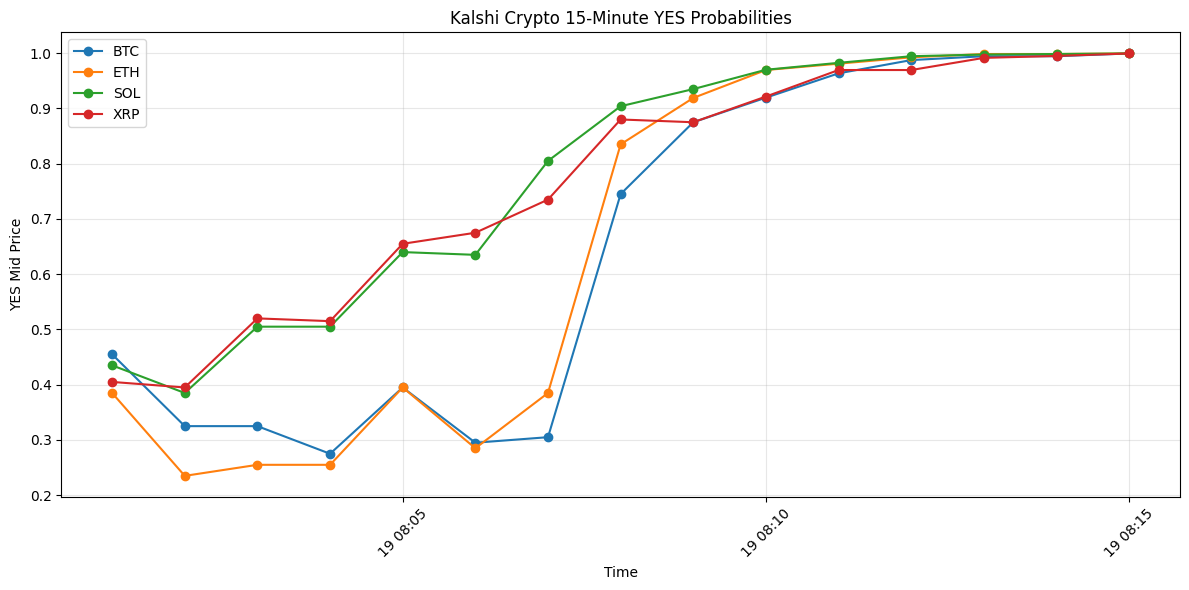

In [39]:
plt.figure(figsize=(12, 6))

for coin in ["BTC", "ETH", "SOL", "XRP"]:
    plt.plot(
        prices.index,
        prices[coin],
        marker="o",
        label=coin
    )

plt.title("Kalshi Crypto 15-Minute YES Probabilities")
plt.xlabel("Time")
plt.ylabel("YES Mid Price")
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

# 5. Expanding the Experiment

Instead of relying on one 15-minute contract, I expanded the dataset from **9:30 AM to 2:00 PM IST**.

That gives:

- **19 consecutive 15-minute windows**
- **4 crypto markets per window**
- **76 individual Kalshi contracts**

Markets tested:

**BTC • ETH • SOL • XRP**

In [47]:
coins = {
    "BTC": "KXBTC15M",
    "ETH": "KXETH15M",
    "SOL": "KXSOL15M",
    "XRP": "KXXRP15M"
}

# 9:30 AM → 2:00 PM IST
window_start = pd.Timestamp("2026-09-19 09:30:00", tz="Asia/Kolkata")
window_end   = pd.Timestamp("2026-09-19 14:00:00", tz="Asia/Kolkata")

min_close_ts = int(window_start.timestamp())
max_close_ts = int(window_end.timestamp())

market_rows = []

for coin, series in coins.items():

    r = requests.get(
        f"{BASE_URL}/markets",
        params={
            "series_ticker": series,
            "min_close_ts": min_close_ts,
            "max_close_ts": max_close_ts,
            "limit": 1000
        }
    )

    print(coin, r.status_code)

    for m in r.json().get("markets", []):
        market_rows.append({
            "coin": coin,
            "ticker": m["ticker"],
            "close_time": m["close_time"]
        })

market_list = pd.DataFrame(market_rows)

market_list["close_time"] = pd.to_datetime(
    market_list["close_time"],
    utc=True
).dt.tz_convert("Asia/Kolkata")

market_list = market_list.sort_values(
    ["close_time", "coin"]
).reset_index(drop=True)

display(market_list)
print("\nTotal markets:", len(market_list))

BTC 200
ETH 200
SOL 200
XRP 200


,coin,ticker,close_time
0,BTC,KXBTC15M-26SEP190000-00,2026-09-19 09:30:00+05:30
1,ETH,KXETH15M-26SEP190000-00,2026-09-19 09:30:00+05:30
2,SOL,KXSOL15M-26SEP190000-00,2026-09-19 09:30:00+05:30
3,XRP,KXXRP15M-26SEP190000-00,2026-09-19 09:30:00+05:30
4,BTC,KXBTC15M-26SEP190015-15,2026-09-19 09:45:00+05:30
...,...,...,...
71,XRP,KXXRP15M-26SEP190415-15,2026-09-19 13:45:00+05:30
72,BTC,KXBTC15M-26SEP190430-30,2026-09-19 14:00:00+05:30
73,ETH,KXETH15M-26SEP190430-30,2026-09-19 14:00:00+05:30
74,SOL,KXSOL15M-26SEP190430-30,2026-09-19 14:00:00+05:30



Total markets: 76


In [49]:
all_candles = {}

print("Ready to download:", len(market_list), "markets")

Ready to download: 76 markets


In [50]:
import time

for _, row in market_list.iterrows():

    coin = row["coin"]
    ticker = row["ticker"]
    close_time = row["close_time"]

    # Skip markets we already downloaded
    if ticker in all_candles:
        continue

    series = coins[coin]
    start = close_time - pd.Timedelta(minutes=15)

    while True:

        r = requests.get(
            f"{BASE_URL}/markets/candlesticks",
            params={
                "series_ticker": series,
                "market_tickers": ticker,
                "start_ts": int(start.timestamp()),
                "end_ts": int(close_time.timestamp()),
                "period_interval": 1
            }
        )

        if r.status_code == 200:

            data = r.json()

            if data.get("markets"):
                candles = data["markets"][0]["candlesticks"]

                all_candles[ticker] = {
                    "coin": coin,
                    "close_time": close_time,
                    "candles": candles
                }

                print(
                    coin,
                    close_time.strftime("%H:%M"),
                    "|",
                    len(candles),
                    "candles"
                )

            break

        elif r.status_code == 429:
            print("Rate limited — waiting 5 sec...")
            time.sleep(5)

        else:
            print("ERROR:", ticker, r.status_code)
            break

    # Slow down every request
    time.sleep(1)

BTC 09:30 | 15 candles
ETH 09:30 | 15 candles
SOL 09:30 | 15 candles
XRP 09:30 | 15 candles
BTC 09:45 | 15 candles
ETH 09:45 | 15 candles
SOL 09:45 | 15 candles
XRP 09:45 | 15 candles
BTC 10:00 | 15 candles
ETH 10:00 | 15 candles
SOL 10:00 | 15 candles
XRP 10:00 | 15 candles
BTC 10:15 | 15 candles
ETH 10:15 | 15 candles
SOL 10:15 | 15 candles
XRP 10:15 | 15 candles
BTC 10:30 | 15 candles
ETH 10:30 | 15 candles
SOL 10:30 | 15 candles
XRP 10:30 | 15 candles
BTC 10:45 | 15 candles
ETH 10:45 | 15 candles
SOL 10:45 | 15 candles
XRP 10:45 | 15 candles
BTC 11:00 | 15 candles
ETH 11:00 | 15 candles
SOL 11:00 | 15 candles
XRP 11:00 | 15 candles
BTC 11:15 | 15 candles
ETH 11:15 | 15 candles
SOL 11:15 | 15 candles
XRP 11:15 | 15 candles
BTC 11:30 | 15 candles
ETH 11:30 | 15 candles
SOL 11:30 | 15 candles
XRP 11:30 | 15 candles
BTC 11:45 | 15 candles
ETH 11:45 | 15 candles
SOL 11:45 | 15 candles
XRP 11:45 | 15 candles
BTC 12:00 | 15 candles
ETH 12:00 | 15 candles
SOL 12:00 | 15 candles
XRP 12:00 |

In [51]:
print("Downloaded markets:", len(all_candles))
print("Expected markets:", len(market_list))

missing = [
    ticker
    for ticker in market_list["ticker"]
    if ticker not in all_candles
]

print("Missing markets:", len(missing))

if missing:
    print(missing)
else:
    print("✓ Complete dataset")

Downloaded markets: 76
Expected markets: 76
Missing markets: 0
✓ Complete dataset


In [52]:
rows = []

for ticker, info in all_candles.items():

    coin = info["coin"]
    close_time = info["close_time"]

    for c in info["candles"]:

        yes_bid = float(c["yes_bid"]["close_dollars"])
        yes_ask = float(c["yes_ask"]["close_dollars"])

        rows.append({
            "coin": coin,
            "ticker": ticker,
            "contract_close": close_time,
            "timestamp": pd.to_datetime(
                c["end_period_ts"],
                unit="s",
                utc=True
            ).tz_convert("Asia/Kolkata"),
            "yes_bid": yes_bid,
            "yes_ask": yes_ask,
            "yes_mid": (yes_bid + yes_ask) / 2
        })

df = pd.DataFrame(rows)

df = df.sort_values(
    ["contract_close", "timestamp", "coin"]
).reset_index(drop=True)

display(df.head(20))

print("Total candles:", len(df))

,coin,ticker,contract_close,timestamp,yes_bid,yes_ask,yes_mid
0,BTC,KXBTC15M-26SEP190000-00,2026-09-19 09:30:00+05:30,2026-09-19 09:16:00+05:30,0.51,0.52,0.515
1,ETH,KXETH15M-26SEP190000-00,2026-09-19 09:30:00+05:30,2026-09-19 09:16:00+05:30,0.48,0.49,0.485
2,SOL,KXSOL15M-26SEP190000-00,2026-09-19 09:30:00+05:30,2026-09-19 09:16:00+05:30,0.40,0.41,0.405
3,XRP,KXXRP15M-26SEP190000-00,2026-09-19 09:30:00+05:30,2026-09-19 09:16:00+05:30,0.39,0.42,0.405
4,BTC,KXBTC15M-26SEP190000-00,2026-09-19 09:30:00+05:30,2026-09-19 09:17:00+05:30,0.58,0.59,0.585
5,ETH,KXETH15M-26SEP190000-00,2026-09-19 09:30:00+05:30,2026-09-19 09:17:00+05:30,0.52,0.53,0.525
6,SOL,KXSOL15M-26SEP190000-00,2026-09-19 09:30:00+05:30,2026-09-19 09:17:00+05:30,0.32,0.33,0.325
7,XRP,KXXRP15M-26SEP190000-00,2026-09-19 09:30:00+05:30,2026-09-19 09:17:00+05:30,0.42,0.43,0.425
8,BTC,KXBTC15M-26SEP190000-00,2026-09-19 09:30:00+05:30,2026-09-19 09:18:00+05:30,0.60,0.61,0.605
9,ETH,KXETH15M-26SEP190000-00,2026-09-19 09:30:00+05:30,2026-09-19 09:18:00+05:30,0.53,0.54,0.535


Total candles: 1140


In [53]:
df["change"] = (
    df.groupby(["ticker"])["yes_mid"]
      .diff()
)

changes_df = df.dropna(subset=["change"]).copy()

display(changes_df.head(20))

print("Total change observations:", len(changes_df))

,coin,ticker,contract_close,timestamp,yes_bid,yes_ask,yes_mid,change
4,BTC,KXBTC15M-26SEP190000-00,2026-09-19 09:30:00+05:30,2026-09-19 09:17:00+05:30,0.58,0.59,0.585,0.070
5,ETH,KXETH15M-26SEP190000-00,2026-09-19 09:30:00+05:30,2026-09-19 09:17:00+05:30,0.52,0.53,0.525,0.040
6,SOL,KXSOL15M-26SEP190000-00,2026-09-19 09:30:00+05:30,2026-09-19 09:17:00+05:30,0.32,0.33,0.325,-0.080
7,XRP,KXXRP15M-26SEP190000-00,2026-09-19 09:30:00+05:30,2026-09-19 09:17:00+05:30,0.42,0.43,0.425,0.020
8,BTC,KXBTC15M-26SEP190000-00,2026-09-19 09:30:00+05:30,2026-09-19 09:18:00+05:30,0.60,0.61,0.605,0.020
9,ETH,KXETH15M-26SEP190000-00,2026-09-19 09:30:00+05:30,2026-09-19 09:18:00+05:30,0.53,0.54,0.535,0.010
10,SOL,KXSOL15M-26SEP190000-00,2026-09-19 09:30:00+05:30,2026-09-19 09:18:00+05:30,0.41,0.43,0.420,0.095
11,XRP,KXXRP15M-26SEP190000-00,2026-09-19 09:30:00+05:30,2026-09-19 09:18:00+05:30,0.48,0.49,0.485,0.060
12,BTC,KXBTC15M-26SEP190000-00,2026-09-19 09:30:00+05:30,2026-09-19 09:19:00+05:30,0.61,0.62,0.615,0.010
13,ETH,KXETH15M-26SEP190000-00,2026-09-19 09:30:00+05:30,2026-09-19 09:19:00+05:30,0.49,0.51,0.500,-0.035


Total change observations: 1064


In [54]:
wide_changes = changes_df.pivot_table(
    index=["contract_close", "timestamp"],
    columns="coin",
    values="change"
)

# Keep only minutes where all 4 markets have data
wide_changes = wide_changes[
    ["BTC", "ETH", "SOL", "XRP"]
].dropna()

display(wide_changes.head(20))

print("Synchronized minutes:", len(wide_changes))

coin                                                    BTC     ETH     SOL  \
contract_close            timestamp                                           
2026-09-19 09:30:00+05:30 2026-09-19 09:17:00+05:30  0.0700  0.0400 -0.0800   
                          2026-09-19 09:18:00+05:30  0.0200  0.0100  0.0950   
                          2026-09-19 09:19:00+05:30  0.0100 -0.0350  0.0350   
                          2026-09-19 09:20:00+05:30 -0.0100 -0.0500  0.0750   
                          2026-09-19 09:21:00+05:30 -0.1900 -0.1850 -0.2050   
                          2026-09-19 09:22:00+05:30  0.1800  0.1200 -0.0600   
                          2026-09-19 09:23:00+05:30 -0.0500 -0.0500 -0.1150   
                          2026-09-19 09:24:00+05:30  0.0500 -0.0700  0.0850   
                          2026-09-19 09:25:00+05:30  0.0200 -0.0500 -0.0400   
                          2026-09-19 09:26:00+05:30  0.0500  0.0100  0.0100   
                          2026-09-19 09:27:00+05:30  0.1400 -0.0400 -0.0600   
                          2026-09-19 09:28:00+05:30 -0.6600 -0.1265 -0.1035   
                          2026-09-19 09:29:00+05:30 -0.1160 -0.0470 -0.0370   
                          2026-09-19 09:30:00+05:30 -0.0285 -0.0110 -0.0040   
2026-09-19 09:45:00+05:30 2026-09-19 09:32:00+05:30 -0.1000 -0.0300  0.0450   
                          2026-09-19 09:33:00+05:30  0.0300  0.0600  0.1000   
                          2026-09-19 09:34:00+05:30  0.1900  0.2200 -0.1950   
                          2026-09-19 09:35:00+05:30 -0.0500  0.0200  0.0200   
                          2026-09-19 09:36:00+05:30 -0.0100  0.0400  0.0200   
                          2026-09-19 09:37:00+05:30 -0.0100 -0.0600 -0.0100   

coin                                                    XRP  
contract_close            timestamp                          
2026-09-19 09:30:00+05:30 2026-09-19 09:17:00+05:30  0.0200  
                          2026-09-19 09:18:00+05:30  0.0600  
                          2026-09-19 09:19:00+05:30  0.2400  
                          2026-09-19 09:20:00+05:30  0.0600  
                          2026-09-19 09:21:00+05:30 -0.0550  
                          2026-09-19 09:22:00+05:30  0.1550  
                          2026-09-19 09:23:00+05:30 -0.0100  
                          2026-09-19 09:24:00+05:30  0.0495  
                          2026-09-19 09:25:00+05:30  0.0475  
                          2026-09-19 09:26:00+05:30  0.0105  
                          2026-09-19 09:27:00+05:30  0.0080  
                          2026-09-19 09:28:00+05:30 -0.0030  
                          2026-09-19 09:29:00+05:30  0.0065  
                          2026-09-19 09:30:00+05:30  0.0055  
2026-09-19 09:45:00+05:30 2026-09-19 09:32:00+05:30 -0.0100  
                          2026-09-19 09:33:00+05:30  0.2700  
                          2026-09-19 09:34:00+05:30  0.0000  
                          2026-09-19 09:35:00+05:30  0.0650  
                          2026-09-19 09:36:00+05:30  0.0100  
                          2026-09-19 09:37:00+05:30  0.0750

Synchronized minutes: 266


## 8. Overall Correlation Across 19 Windows

Now the relationships are calculated across all 19 windows instead of one contract.

### Results

- BTC ↔ ETH: **0.6687**
- ETH ↔ SOL: **0.4849**
- ETH ↔ XRP: **0.4633**
- SOL ↔ XRP: **0.4610**
- BTC ↔ SOL: **0.4667**
- BTC ↔ XRP: **0.4014**

### Main Finding

**BTC and ETH had the strongest same-minute relationship at 0.6687.**

They clearly tend to move together — but simultaneous correlation by itself doesn't tell us which market moves first.

In [55]:
overall_corr = wide_changes.corr()

print("OVERALL CHANGE CORRELATION — 19 CONTRACTS")
display(overall_corr.round(4))

OVERALL CHANGE CORRELATION — 19 CONTRACTS


coin,BTC,ETH,SOL,XRP
coin,,,,
BTC,1.0000,0.6687,0.4667,0.4014
ETH,0.6687,1.0000,0.4849,0.4633
SOL,0.4667,0.4849,1.0000,0.4610
XRP,0.4014,0.4633,0.4610,1.0000


# 9. Searching for a Lead-Lag Edge

Now for the more interesting question:

> Does a move in one Kalshi market contain information about what another market does one minute later?

For every possible pair, I compare:

**Leader change at minute t → Follower change at minute t + 1**

The shift is performed separately inside each 15-minute contract so information never leaks between contracts.

In [56]:
coins_list = ["BTC", "ETH", "SOL", "XRP"]

lead_lag_results = []

for leader in coins_list:
    for follower in coins_list:

        if leader == follower:
            continue

        pairs = []

        # IMPORTANT: shift separately inside each contract
        for close_time, group in wide_changes.groupby(level="contract_close"):

            g = group.droplevel("contract_close")

            temp = pd.DataFrame({
                "leader_now": g[leader],
                "follower_next": g[follower].shift(-1)
            }).dropna()

            pairs.append(temp)

        combined = pd.concat(pairs)

        corr = combined["leader_now"].corr(
            combined["follower_next"]
        )

        lead_lag_results.append({
            "Leader": leader,
            "Follower": follower,
            "Lead_Correlation": corr,
            "N": len(combined)
        })

lead_lag_all = pd.DataFrame(lead_lag_results)

lead_lag_all = lead_lag_all.sort_values(
    "Lead_Correlation",
    ascending=False
)

display(lead_lag_all.round(4))

,Leader,Follower,Lead_Correlation,N
7,SOL,ETH,0.1903,247
3,ETH,BTC,0.1487,247
0,BTC,ETH,0.1418,247
8,SOL,XRP,0.1391,247
5,ETH,XRP,0.1383,247
6,SOL,BTC,0.1225,247
10,XRP,ETH,0.1184,247
9,XRP,BTC,0.1081,247
4,ETH,SOL,0.0996,247
11,XRP,SOL,0.0527,247


## Lead-Lag Results

The strongest one-minute lead-lag relationship was:

### SOL → ETH = 0.1903

Other notable relationships:

- ETH → BTC: **0.1487**
- BTC → ETH: **0.1418**
- SOL → XRP: **0.1391**
- ETH → XRP: **0.1383**
- SOL → BTC: **0.1225**

### Interesting Pattern

SOL appears as the leader in several of the strongest relationships.

This suggests a hypothesis worth testing:

> **Does Kalshi's SOL market sometimes react before its ETH market?**

## 10. Is SOL → ETH Consistent?

One overall correlation could be caused by only a few unusual periods.

So I calculate the **SOL → ETH lead correlation separately for each of the 19 windows**.

If the relationship is real enough to investigate further, I would want it to appear repeatedly rather than being driven by one contract.

In [57]:
sol_eth_by_contract = []

for close_time, group in wide_changes.groupby(level="contract_close"):

    g = group.droplevel("contract_close")

    temp = pd.DataFrame({
        "SOL_now": g["SOL"],
        "ETH_next": g["ETH"].shift(-1)
    }).dropna()

    corr = temp["SOL_now"].corr(temp["ETH_next"])

    sol_eth_by_contract.append({
        "contract_close": close_time,
        "SOL_to_ETH_corr": corr
    })

sol_eth_contracts = pd.DataFrame(sol_eth_by_contract)

display(sol_eth_contracts.round(4))

print(
    "Positive contracts:",
    (sol_eth_contracts["SOL_to_ETH_corr"] > 0).sum(),
    "/",
    len(sol_eth_contracts)
)

print(
    "Median correlation:",
    round(sol_eth_contracts["SOL_to_ETH_corr"].median(), 4)
)

,contract_close,SOL_to_ETH_corr
0,2026-09-19 09:30:00+05:30,-0.5508
1,2026-09-19 09:45:00+05:30,0.0848
2,2026-09-19 10:00:00+05:30,0.0602
3,2026-09-19 10:15:00+05:30,0.8164
4,2026-09-19 10:30:00+05:30,-0.1729
5,2026-09-19 10:45:00+05:30,0.2567
6,2026-09-19 11:00:00+05:30,0.1071
7,2026-09-19 11:15:00+05:30,0.1711
8,2026-09-19 11:30:00+05:30,0.0442
9,2026-09-19 11:45:00+05:30,0.1824


Positive contracts: 14 / 19
Median correlation: 0.1711


### Result

SOL → ETH had a **positive lead correlation in 14 of 19 windows**, or roughly **74%** of the sample.

The median SOL → ETH lead correlation across the windows was approximately **0.171**.

So the relationship was not present everywhere, but it appeared often enough to justify testing an actual trading rule.

# 11. Turning the Pattern Into a Signal

Correlation is interesting, but a trading strategy needs an actual rule.

So I test:

> When SOL's Kalshi YES price makes a sufficiently large move, what happens to ETH's Kalshi YES price during the next minute?

Important:

**"SOL moved 5¢" means the Kalshi SOL YES contract moved by 5 cents — NOT that the spot price of Solana moved by $0.05.**

In [58]:
signal_rows = []

for close_time, group in wide_changes.groupby(level="contract_close"):

    g = group.droplevel("contract_close").copy()

    g["ETH_next"] = g["ETH"].shift(-1)

    # SOL moves at least 5 cents
    signals = g[g["SOL"].abs() >= 0.05].dropna(
        subset=["ETH_next"]
    )

    for timestamp, row in signals.iterrows():

        signal_rows.append({
            "contract_close": close_time,
            "timestamp": timestamp,
            "SOL_move": row["SOL"],
            "ETH_next_move": row["ETH_next"],
            "same_direction": np.sign(row["SOL"]) == np.sign(row["ETH_next"])
        })

signals = pd.DataFrame(signal_rows)

print("SOL ≥5¢ signals:", len(signals))

print(
    "Same direction next minute:",
    round(signals["same_direction"].mean() * 100, 2),
    "%"
)

print(
    "Average ETH next move after SOL UP:",
    round(
        signals.loc[
            signals["SOL_move"] >= 0.05,
            "ETH_next_move"
        ].mean(),
        4
    )
)

print(
    "Average ETH next move after SOL DOWN:",
    round(
        signals.loc[
            signals["SOL_move"] <= -0.05,
            "ETH_next_move"
        ].mean(),
        4
    )
)

SOL ≥5¢ signals: 117
Same direction next minute: 58.12 %
Average ETH next move after SOL UP: 0.0311
Average ETH next move after SOL DOWN: -0.0236


## The 5¢ Signal

When SOL's YES mid-price moved by at least **5¢ in one minute**, there were **117 qualifying signals**.

ETH moved in the same direction during the next minute approximately **58.1% of the time**.

More importantly:

- After a large SOL **UP** move → ETH's next-minute YES move averaged **+3.11¢**
- After a large SOL **DOWN** move → ETH's next-minute YES move averaged **−2.36¢**

This is the first result suggesting a potentially exploitable reaction delay.

In [59]:
threshold_results = []

for threshold in [0.02, 0.03, 0.05, 0.075, 0.10, 0.15]:

    subset = signals.copy() if threshold == 0.05 else None

    rows_temp = []

    for close_time, group in wide_changes.groupby(level="contract_close"):

        g = group.droplevel("contract_close").copy()
        g["ETH_next"] = g["ETH"].shift(-1)

        temp = g[
            g["SOL"].abs() >= threshold
        ].dropna(subset=["ETH_next"])

        for _, row in temp.iterrows():

            rows_temp.append({
                "SOL": row["SOL"],
                "ETH_next": row["ETH_next"],
                "same_direction":
                    np.sign(row["SOL"]) ==
                    np.sign(row["ETH_next"])
            })

    temp_df = pd.DataFrame(rows_temp)

    threshold_results.append({
        "SOL_threshold": threshold,
        "N": len(temp_df),
        "same_direction_pct":
            temp_df["same_direction"].mean() * 100,
        "avg_ETH_move":
            temp_df["ETH_next"].abs().mean()
    })

threshold_table = pd.DataFrame(threshold_results)

display(threshold_table.round(4))

,SOL_threshold,N,same_direction_pct,avg_ETH_move
0,0.020,171,60.2339,0.0775
1,0.030,150,59.3333,0.0809
2,0.050,117,58.1197,0.0896
3,0.075,89,58.4270,0.0910
4,0.100,57,57.8947,0.0883
5,0.150,33,60.6061,0.0952


## Candidate Threshold: 7.5¢

The **7.5¢ threshold** gave an interesting balance between sample size and simulated performance:

- **89 trades**
- **58.43% win rate**
- **+3.18¢ average P&L per trade**
- **+1.4¢ median P&L**
- **+$2.834 total simulated P&L**

This becomes my **candidate rule** for further testing.

Important: I selected this threshold after looking at the same dataset, so this is **in-sample** and may be overfit.

In [60]:
pnl_results = []

for threshold in [0.02, 0.03, 0.05, 0.075, 0.10, 0.15]:

    trades = []

    for close_time, group in wide_changes.groupby(level="contract_close"):

        g = group.droplevel("contract_close").copy()
        g["ETH_next"] = g["ETH"].shift(-1)

        temp = g[
            g["SOL"].abs() >= threshold
        ].dropna(subset=["ETH_next"])

        for _, row in temp.iterrows():

            # If SOL went up -> long ETH YES
            # If SOL went down -> effectively short ETH YES
            raw_pnl = np.sign(row["SOL"]) * row["ETH_next"]

            trades.append(raw_pnl)

    trades = pd.Series(trades)

    pnl_results.append({
        "threshold": threshold,
        "N": len(trades),
        "win_rate_%": (trades > 0).mean() * 100,
        "avg_raw_pnl": trades.mean(),
        "median_raw_pnl": trades.median(),
        "total_raw_pnl": trades.sum()
    })

pnl_table = pd.DataFrame(pnl_results)

display(pnl_table.round(4))

,threshold,N,win_rate_%,avg_raw_pnl,median_raw_pnl,total_raw_pnl
0,0.020,171,60.2339,0.0200,0.0150,3.4270
1,0.030,150,59.3333,0.0233,0.0155,3.5025
2,0.050,117,58.1197,0.0271,0.0180,3.1740
3,0.075,89,58.4270,0.0408,0.0200,3.6285
4,0.100,57,57.8947,0.0412,0.0200,2.3510
5,0.150,33,60.6061,0.0503,0.0380,1.6595


## Testing Different SOL Signal Thresholds

Now I test whether **larger SOL moves produce a stronger ETH signal**.

I test six thresholds:

**2¢ • 3¢ • 5¢ • 7.5¢ • 10¢ • 15¢**

For every qualifying SOL move:

- **SOL goes UP → bet on ETH going UP next minute**
- **SOL goes DOWN → bet on ETH going DOWN next minute**

For each threshold, I calculate:

- **N:** Number of signals/trades
- **Win Rate:** % where ETH moved in the predicted direction
- **Average Raw P&L:** Average ETH move in our predicted direction
- **Median Raw P&L:** Typical ETH move
- **Total Raw P&L:** Sum of all predicted ETH movements

### Important

This is a **raw signal test**, not yet a realistic trading backtest.

It does **not account for the bid-ask spread, fees, slippage or execution**. The next step is to test whether the signal survives actual bid/ask prices.

## Preparing Executable Market Prices

Now I synchronize the **YES bid, YES ask, and YES mid-price** for BTC, ETH, SOL and XRP at every minute.

This is important because the **mid-price tells us where the market is**, but the **bid and ask tell us the prices we could actually buy and sell at**.

I only keep timestamps where quote data exists for **all four markets**.

This lets us move from a theoretical signal test to a more realistic **spread-adjusted trading simulation**.

In [61]:
wide_quotes = df.pivot_table(
    index=["contract_close", "timestamp"],
    columns="coin",
    values=["yes_bid", "yes_ask", "yes_mid"]
)

wide_quotes = wide_quotes.dropna()

display(wide_quotes.head())

print("Synchronized quote rows:", len(wide_quotes))

yes_ask                    \
coin                                                    BTC   ETH   SOL   XRP   
contract_close            timestamp                                             
2026-09-19 09:30:00+05:30 2026-09-19 09:16:00+05:30    0.52  0.49  0.41  0.42   
                          2026-09-19 09:17:00+05:30    0.59  0.53  0.33  0.43   
                          2026-09-19 09:18:00+05:30    0.61  0.54  0.43  0.49   
                          2026-09-19 09:19:00+05:30    0.62  0.51  0.46  0.73   
                          2026-09-19 09:20:00+05:30    0.61  0.46  0.54  0.79   

                                                    yes_bid                    \
coin                                                    BTC   ETH   SOL   XRP   
contract_close            timestamp                                             
2026-09-19 09:30:00+05:30 2026-09-19 09:16:00+05:30    0.51  0.48  0.40  0.39   
                          2026-09-19 09:17:00+05:30    0.58  0.52  0.32  0.42   
                          2026-09-19 09:18:00+05:30    0.60  0.53  0.41  0.48   
                          2026-09-19 09:19:00+05:30    0.61  0.49  0.45  0.72   
                          2026-09-19 09:20:00+05:30    0.60  0.44  0.52  0.78   

                                                    yes_mid                \
coin                                                    BTC    ETH    SOL   
contract_close            timestamp                                         
2026-09-19 09:30:00+05:30 2026-09-19 09:16:00+05:30   0.515  0.485  0.405   
                          2026-09-19 09:17:00+05:30   0.585  0.525  0.325   
                          2026-09-19 09:18:00+05:30   0.605  0.535  0.420   
                          2026-09-19 09:19:00+05:30   0.615  0.500  0.455   
                          2026-09-19 09:20:00+05:30   0.605  0.450  0.530   

                                                            
coin                                                   XRP  
contract_close            timestamp                         
2026-09-19 09:30:00+05:30 2026-09-19 09:16:00+05:30  0.405  
                          2026-09-19 09:17:00+05:30  0.425  
                          2026-09-19 09:18:00+05:30  0.485  
                          2026-09-19 09:19:00+05:30  0.725  
                          2026-09-19 09:20:00+05:30  0.785

Synchronized quote rows: 285


## Building the Spread-Adjusted Trading Simulation

Now I turn the SOL → ETH signal into simulated trades using **actual bid and ask prices** instead of mid-prices.

### Trading Logic

**If SOL moves UP:**
- Buy **ETH YES** at the current **ask**
- Sell one minute later at the **bid**

**If SOL moves DOWN:**
- Buy **ETH NO** at its current ask
- Sell one minute later at its bid

### P&L

**P&L = Exit Price − Entry Price**

Using the ask to enter and bid to exit means the simulation now accounts for the **bid-ask spread**, making it more realistic than the previous raw P&L test.

At this stage, every non-zero SOL move is included; the signal threshold is applied in the next step.

In [62]:
# Flatten the MultiIndex columns
quotes = wide_quotes.copy()

quotes.columns = [
    f"{metric}_{coin}"
    for metric, coin in quotes.columns
]

execution_trades = []

for close_time, group in quotes.groupby(level="contract_close"):

    g = group.droplevel("contract_close").copy()

    # SOL movement this minute
    g["SOL_change"] = g["yes_mid_SOL"].diff()

    # ETH executable prices one minute later
    g["ETH_next_bid"] = g["yes_bid_ETH"].shift(-1)
    g["ETH_next_ask"] = g["yes_ask_ETH"].shift(-1)

    for timestamp, row in g.iterrows():

        sol_move = row["SOL_change"]

        if pd.isna(sol_move):
            continue

        if pd.isna(row["ETH_next_bid"]) or pd.isna(row["ETH_next_ask"]):
            continue

        # SOL UP → buy ETH YES
        if sol_move > 0:

            entry = row["yes_ask_ETH"]
            exit_price = row["ETH_next_bid"]

        # SOL DOWN → buy ETH NO
        elif sol_move < 0:

            entry = 1 - row["yes_bid_ETH"]
            exit_price = 1 - row["ETH_next_ask"]

        else:
            continue

        execution_trades.append({
            "contract_close": close_time,
            "timestamp": timestamp,
            "SOL_move": sol_move,
            "entry": entry,
            "exit": exit_price,
            "pnl": exit_price - entry
        })

execution_trades = pd.DataFrame(execution_trades)

print("Trades available:", len(execution_trades))
display(execution_trades.head())

Trades available: 242


,contract_close,timestamp,SOL_move,entry,exit,pnl
0,2026-09-19 09:30:00+05:30,2026-09-19 09:17:00+05:30,-0.080,0.48,0.46,-0.02
1,2026-09-19 09:30:00+05:30,2026-09-19 09:18:00+05:30,0.095,0.54,0.49,-0.05
2,2026-09-19 09:30:00+05:30,2026-09-19 09:19:00+05:30,0.035,0.51,0.44,-0.07
3,2026-09-19 09:30:00+05:30,2026-09-19 09:20:00+05:30,0.075,0.46,0.26,-0.20
4,2026-09-19 09:30:00+05:30,2026-09-19 09:21:00+05:30,-0.205,0.74,0.61,-0.13


# 12. Making the Simulation More Realistic

Mid-prices aren't necessarily prices I could actually trade at.

So now I use the historical **bid and ask**.

### Strategy

**SOL UP ≥ threshold**
→ Buy ETH YES at the ask  
→ Sell ETH YES one minute later at the bid

**SOL DOWN ≥ threshold**
→ Buy ETH NO at the ask  
→ Sell ETH NO one minute later at the bid

This forces the simulated strategy to overcome the **bid-ask spread**.

In [63]:
thresholds = [0.02, 0.03, 0.05, 0.075, 0.10, 0.15]

spread_results = []

for threshold in thresholds:

    t = execution_trades[
        execution_trades["SOL_move"].abs() >= threshold
    ]

    spread_results.append({
        "threshold": threshold,
        "N": len(t),
        "win_rate_%": (t["pnl"] > 0).mean() * 100,
        "avg_pnl": t["pnl"].mean(),
        "median_pnl": t["pnl"].median(),
        "total_pnl": t["pnl"].sum()
    })

spread_table = pd.DataFrame(spread_results)

display(spread_table.round(4))

,threshold,N,win_rate_%,avg_pnl,median_pnl,total_pnl
0,0.020,171,55.5556,0.0113,0.010,1.931
1,0.030,150,56.0000,0.0145,0.010,2.182
2,0.050,117,56.4103,0.0180,0.010,2.110
3,0.075,89,58.4270,0.0318,0.014,2.834
4,0.100,57,57.8947,0.0327,0.011,1.863
5,0.150,33,60.6061,0.0421,0.030,1.388


In [64]:
candidate_threshold = 0.075

candidate = execution_trades[
    execution_trades["SOL_move"].abs() >= candidate_threshold
].copy()

contract_performance = (
    candidate
    .groupby("contract_close")
    .agg(
        trades=("pnl", "size"),
        avg_pnl=("pnl", "mean"),
        total_pnl=("pnl", "sum")
    )
    .reset_index()
)

display(contract_performance.round(4))

print(
    "Profitable contracts:",
    (contract_performance["total_pnl"] > 0).sum(),
    "/",
    len(contract_performance)
)

print(
    "Median contract PnL:",
    round(contract_performance["total_pnl"].median(), 4)
)

,contract_close,trades,avg_pnl,total_pnl
0,2026-09-19 09:30:00+05:30,7,-0.0506,-0.354
1,2026-09-19 09:45:00+05:30,5,0.0434,0.217
2,2026-09-19 10:00:00+05:30,2,-0.0450,-0.090
3,2026-09-19 10:15:00+05:30,1,0.0700,0.070
4,2026-09-19 10:30:00+05:30,8,-0.0018,-0.014
5,2026-09-19 10:45:00+05:30,3,0.0440,0.132
6,2026-09-19 11:00:00+05:30,4,0.1025,0.410
7,2026-09-19 11:15:00+05:30,10,0.0282,0.282
8,2026-09-19 11:30:00+05:30,5,-0.0428,-0.214
9,2026-09-19 11:45:00+05:30,8,0.0620,0.496


Profitable contracts: 14 / 19
Median contract PnL: 0.132


# 14. Does It Work in Both Directions?

### SOL UP → Buy ETH YES

- **45 trades**
- **57.78% win rate**
- **+3.52¢ average P&L**

### SOL DOWN → Buy ETH NO

- **44 trades**
- **59.09% win rate**
- **+2.85¢ average P&L**

Both directions produced positive average simulated P&L in this sample.

In [65]:
up_trades = candidate[
    candidate["SOL_move"] > 0
]

down_trades = candidate[
    candidate["SOL_move"] < 0
]

direction_results = pd.DataFrame([
    {
        "direction": "SOL UP → ETH YES",
        "N": len(up_trades),
        "win_rate_%": (up_trades["pnl"] > 0).mean() * 100,
        "avg_pnl": up_trades["pnl"].mean(),
        "median_pnl": up_trades["pnl"].median()
    },
    {
        "direction": "SOL DOWN → ETH NO",
        "N": len(down_trades),
        "win_rate_%": (down_trades["pnl"] > 0).mean() * 100,
        "avg_pnl": down_trades["pnl"].mean(),
        "median_pnl": down_trades["pnl"].median()
    }
])

display(direction_results.round(4))

,direction,N,win_rate_%,avg_pnl,median_pnl
0,SOL UP → ETH YES,45,57.7778,0.0352,0.011
1,SOL DOWN → ETH NO,44,59.0909,0.0285,0.030


# 15. Does the Strategy Work Across Different Windows?

At the 7.5¢ threshold:

**14 of the 19 windows were profitable.**

Median total P&L per window:

**+$0.132**

This matters because the overall result is not coming from only one unusually profitable 15-minute period.

In [66]:
leader_results = []

for leader in ["BTC", "SOL", "XRP"]:

    trades = []

    for close_time, group in quotes.groupby(level="contract_close"):

        g = group.droplevel("contract_close").copy()

        g["leader_change"] = g[f"yes_mid_{leader}"].diff()
        g["ETH_next_bid"] = g["yes_bid_ETH"].shift(-1)
        g["ETH_next_ask"] = g["yes_ask_ETH"].shift(-1)

        signals = g[
            g["leader_change"].abs() >= candidate_threshold
        ].dropna(subset=["ETH_next_bid", "ETH_next_ask"])

        for _, row in signals.iterrows():

            # Leader UP → buy ETH YES
            if row["leader_change"] > 0:
                entry = row["yes_ask_ETH"]
                exit_price = row["ETH_next_bid"]

            # Leader DOWN → buy ETH NO
            else:
                entry = 1 - row["yes_bid_ETH"]
                exit_price = 1 - row["ETH_next_ask"]

            trades.append(exit_price - entry)

    trades = pd.Series(trades)

    leader_results.append({
        "leader": leader,
        "N": len(trades),
        "win_rate_%": (trades > 0).mean() * 100,
        "avg_pnl": trades.mean(),
        "median_pnl": trades.median(),
        "total_pnl": trades.sum()
    })

leader_table = pd.DataFrame(leader_results)

display(
    leader_table.sort_values(
        "avg_pnl",
        ascending=False
    ).round(4)
)

,leader,N,win_rate_%,avg_pnl,median_pnl,total_pnl
1,SOL,89,58.4270,0.0318,0.014,2.834
2,XRP,87,52.8736,0.0134,0.006,1.162
0,BTC,101,59.4059,0.0080,0.011,0.804


# 16. Is SOL Actually Special?

Using the same 7.5¢ threshold:

| Leader → ETH | Trades | Win Rate | Avg P&L | Total P&L |
|---|---:|---:|---:|---:|
| SOL → ETH | 89 | 58.43% | +3.18¢ | +$2.834 |
| XRP → ETH | 87 | 52.87% | +1.34¢ | +$1.162 |
| BTC → ETH | 101 | 59.41% | +0.80¢ | +$0.804 |

### Insight

BTC actually had a slightly higher win rate than SOL.

However, **SOL generated substantially larger average simulated P&L per trade**.

So win rate alone does not tell us which signal performed better.

# 17. Could This Just Be Random?

I bootstrap the **89 SOL → ETH simulated trades 10,000 times** to estimate how uncertain the average P&L is.

The idea is simple:

> If I repeatedly resample these trades, does the average simulated profit usually remain above zero?

In [67]:
np.random.seed(42)

observed_mean = candidate["pnl"].mean()

bootstrap_means = []

for _ in range(10000):

    sample = candidate["pnl"].sample(
        n=len(candidate),
        replace=True
    )

    bootstrap_means.append(sample.mean())

bootstrap_means = np.array(bootstrap_means)

lower = np.percentile(bootstrap_means, 2.5)
upper = np.percentile(bootstrap_means, 97.5)

print("Number of trades:", len(candidate))
print("Average PnL:", round(observed_mean, 4))
print(
    "95% bootstrap CI:",
    round(lower, 4),
    "to",
    round(upper, 4)
)

print(
    "Bootstrap means > 0:",
    round((bootstrap_means > 0).mean() * 100, 2),
    "%"
)

Number of trades: 89
Average PnL: 0.0318
95% bootstrap CI: 0.0064 to 0.0574
Bootstrap means > 0: 99.38 %


### Bootstrap Result

- **89 trades**
- Average P&L: **+3.18¢**
- 95% bootstrap interval: **+0.64¢ to +5.74¢**
- Bootstrap averages above zero: **99.38%**

This is encouraging, but it is not proof of a live edge. The trades may not be fully independent, and the strategy itself was selected using this dataset.

# 18. Simulated Capital & ROI

For every qualifying SOL signal, I simulate buying **one ETH contract** at the executable entry price.

### Results

- **89 simulated trades**
- **52 winners**
- **37 losing/non-winning trades**
- **$53.85 cumulative capital deployed**
- **$56.68 returned**
- **+$2.834 simulated profit**
- **5.26% return on cumulative capital deployed**

The $53.85 is the total entry cost summed across all trades, not necessarily the starting bankroll required, since capital can be reused after trades close.

In [78]:
# ============================================================

threshold = 0.1000
rows = []

for leader in ["BTC", "XRP", "SOL"]:

    signals = []

    for close_time, group in quotes.groupby(level="contract_close"):

        g = group.droplevel("contract_close").copy()

        # Leader movement this minute
        g["leader_change"] = g[f"yes_mid_{leader}"].diff()

        # ETH movement NEXT minute
        g["ETH_change"] = g["yes_mid_ETH"].diff()
        g["ETH_next_change"] = g["ETH_change"].shift(-1)

        temp = g[
            g["leader_change"].abs() >= threshold
        ].dropna(subset=["ETH_next_change"])

        signals.append(temp)

    signals = pd.concat(signals)

    up = signals[signals["leader_change"] > 0]
    down = signals[signals["leader_change"] < 0]

    rows.append({
        "Leader → ETH": f"{leader} → ETH",
        "Signals": len(signals),
        "Avg ETH move after leader UP": up["ETH_next_change"].mean(),
        "Avg ETH move after leader DOWN": down["ETH_next_change"].mean()
    })

movement_table = pd.DataFrame(rows)

display(movement_table.round(4))


# ============================================================
# CAPITAL + ROI FOR OUR SOL -> ETH STRATEGY
# ============================================================

sol_trades = execution_trades[
    execution_trades["SOL_move"].abs() >= threshold
].copy()

# We bought ONE contract on every signal.
# Entry = actual simulated purchase price.
sol_trades["capital_used"] = sol_trades["entry"]

total_capital = sol_trades["capital_used"].sum()
total_pnl = sol_trades["pnl"].sum()

total_exit_value = total_capital + total_pnl

roi = (total_pnl / total_capital) * 100

wins = (sol_trades["pnl"] > 0).sum()
losses = (sol_trades["pnl"] <= 0).sum()

print("\n--- SOL → ETH STRATEGY ---")
print("Trades:", len(sol_trades))
print("Winning trades:", wins)
print("Losing/non-winning trades:", losses)

print("\nTotal fake money spent: $", round(total_capital, 2))
print("Total value after exits: $", round(total_exit_value, 2))
print("Profit: $", round(total_pnl, 3))
print("ROI: ", round(roi, 2), "%")

KeyError: 'yes_mid_BTC'

# 19. Final Finding

Across **19 windows, 76 contracts and 1,140 one-minute candles**, I found a possible short-lived SOL → ETH relationship.

### Candidate Strategy

**SOL moves ≥ 7.5¢ → trade ETH in the same direction → exit after 1 minute**

Results:

- **89 trades**
- **58.43% win rate**
- **+3.18¢ average spread-adjusted P&L**
- **+$2.834 total simulated P&L**
- **5.26% return on cumulative capital deployed**

### Important Limitation

This is **not proven live alpha**. The strategy was discovered and tested on the same dataset and does not fully account for fees, slippage, latency, order-book depth, fill probability, market impact or exact intra-minute execution timing.

### Next Step

Freeze the strategy and test it unchanged on completely unseen markets and new trading days.

In [69]:
# ============================================================
# OUT-OF-SAMPLE TEST
# September 19, 2026
# 6:00 PM → 8:00 PM IST
#
# IMPORTANT:
# Frozen strategy:
# SOL moves >= 7.5¢ → trade ETH same direction
# Exit exactly 1 minute later
# ============================================================

import requests
import pandas as pd
import numpy as np

BASE_URL = "https://api.elections.kalshi.com/trade-api/v2"

coins = {
    "BTC": "KXBTC15M",
    "ETH": "KXETH15M",
    "SOL": "KXSOL15M",
    "XRP": "KXXRP15M"
}

# ------------------------------------------------------------
# LOCK THE UNSEEN PERIOD
# ------------------------------------------------------------

window_start = pd.Timestamp(
    "2026-09-19 18:00:00",
    tz="Asia/Kolkata"
)

window_end = pd.Timestamp(
    "2026-09-19 20:00:00",
    tz="Asia/Kolkata"
)

min_close_ts = int(window_start.timestamp())
max_close_ts = int(window_end.timestamp())


# ------------------------------------------------------------
# FIND ALL 15-MINUTE CONTRACTS AUTOMATICALLY
# ------------------------------------------------------------

market_rows = []

for coin, series in coins.items():

    r = requests.get(
        f"{BASE_URL}/markets",
        params={
            "series_ticker": series,
            "min_close_ts": min_close_ts,
            "max_close_ts": max_close_ts,
            "limit": 1000
        }
    )

    print(coin, r.status_code)

    for m in r.json().get("markets", []):

        market_rows.append({
            "coin": coin,
            "ticker": m["ticker"],
            "close_time": m["close_time"]
        })


market_list_new = pd.DataFrame(market_rows)

market_list_new["close_time"] = pd.to_datetime(
    market_list_new["close_time"],
    utc=True
).dt.tz_convert("Asia/Kolkata")

market_list_new = market_list_new.sort_values(
    ["close_time", "coin"]
).reset_index(drop=True)


print("\nMarkets found:", len(market_list_new))

display(market_list_new)

BTC 200
ETH 200
SOL 200
XRP 200

Markets found: 36


,coin,ticker,close_time
0,BTC,KXBTC15M-26SEP190830-30,2026-09-19 18:00:00+05:30
1,ETH,KXETH15M-26SEP190830-30,2026-09-19 18:00:00+05:30
2,SOL,KXSOL15M-26SEP190830-30,2026-09-19 18:00:00+05:30
3,XRP,KXXRP15M-26SEP190830-30,2026-09-19 18:00:00+05:30
4,BTC,KXBTC15M-26SEP190845-45,2026-09-19 18:15:00+05:30
5,ETH,KXETH15M-26SEP190845-45,2026-09-19 18:15:00+05:30
6,SOL,KXSOL15M-26SEP190845-45,2026-09-19 18:15:00+05:30
7,XRP,KXXRP15M-26SEP190845-45,2026-09-19 18:15:00+05:30
8,BTC,KXBTC15M-26SEP190900-00,2026-09-19 18:30:00+05:30
9,ETH,KXETH15M-26SEP190900-00,2026-09-19 18:30:00+05:30


In [70]:

# ============================================================
# KEEP ONLY THE 8 TRUE OUT-OF-SAMPLE WINDOWS
# 18:00 → 20:00 IST trading period
# Contract closes: 18:15 → 20:00
# ============================================================

test_markets = market_list_new[
    (market_list_new["close_time"] > pd.Timestamp(
        "2026-09-19 18:00:00",
        tz="Asia/Kolkata"
    ))
    &
    (market_list_new["close_time"] <= pd.Timestamp(
        "2026-09-19 20:00:00",
        tz="Asia/Kolkata"
    ))
].copy()

print("Contracts:", len(test_markets))
print(
    "Windows:",
    test_markets["close_time"].nunique()
)

display(test_markets)

Contracts: 32
Windows: 8


,coin,ticker,close_time
4,BTC,KXBTC15M-26SEP190845-45,2026-09-19 18:15:00+05:30
5,ETH,KXETH15M-26SEP190845-45,2026-09-19 18:15:00+05:30
6,SOL,KXSOL15M-26SEP190845-45,2026-09-19 18:15:00+05:30
7,XRP,KXXRP15M-26SEP190845-45,2026-09-19 18:15:00+05:30
8,BTC,KXBTC15M-26SEP190900-00,2026-09-19 18:30:00+05:30
9,ETH,KXETH15M-26SEP190900-00,2026-09-19 18:30:00+05:30
10,SOL,KXSOL15M-26SEP190900-00,2026-09-19 18:30:00+05:30
11,XRP,KXXRP15M-26SEP190900-00,2026-09-19 18:30:00+05:30
12,BTC,KXBTC15M-26SEP190915-15,2026-09-19 18:45:00+05:30
13,ETH,KXETH15M-26SEP190915-15,2026-09-19 18:45:00+05:30


In [71]:
# ============================================================
# DOWNLOAD 1-MINUTE CANDLES
# ============================================================

import time

new_candles = {}

for _, row in test_markets.iterrows():

    ticker = row["ticker"]
    coin = row["coin"]
    close_time = row["close_time"]

    # Each contract covers approximately the 15 minutes
    # before its close
    start_time = close_time - pd.Timedelta(minutes=15)

    start_ts = int(start_time.timestamp())
    end_ts = int(close_time.timestamp())

    r = requests.get(
        f"{BASE_URL}/markets/candlesticks",
        params={
            "series_ticker": coins[coin],
            "market_tickers": ticker,
            "start_ts": start_ts,
            "end_ts": end_ts,
            "period_interval": 1
        }
    )

    if r.status_code == 200:

        data = r.json()

        candles = (
            data.get("markets", [{}])[0]
                .get("candlesticks", [])
        )

        new_candles[ticker] = {
            "coin": coin,
            "close_time": close_time,
            "candles": candles
        }

        print(
            coin,
            close_time.strftime("%H:%M"),
            ticker,
            "→",
            len(candles),
            "candles"
        )

    else:

        print(
            "ERROR:",
            coin,
            ticker,
            r.status_code
        )

    # Avoid hammering the API
    time.sleep(0.3)


print("\nDownloaded:", len(new_candles), "/ 32 contracts")

BTC 18:15 KXBTC15M-26SEP190845-45 → 15 candles
ETH 18:15 KXETH15M-26SEP190845-45 → 15 candles
SOL 18:15 KXSOL15M-26SEP190845-45 → 15 candles
XRP 18:15 KXXRP15M-26SEP190845-45 → 15 candles
BTC 18:30 KXBTC15M-26SEP190900-00 → 15 candles
ETH 18:30 KXETH15M-26SEP190900-00 → 15 candles
SOL 18:30 KXSOL15M-26SEP190900-00 → 15 candles
XRP 18:30 KXXRP15M-26SEP190900-00 → 15 candles
BTC 18:45 KXBTC15M-26SEP190915-15 → 15 candles
ETH 18:45 KXETH15M-26SEP190915-15 → 15 candles
SOL 18:45 KXSOL15M-26SEP190915-15 → 15 candles
XRP 18:45 KXXRP15M-26SEP190915-15 → 15 candles
BTC 19:00 KXBTC15M-26SEP190930-30 → 15 candles
ETH 19:00 KXETH15M-26SEP190930-30 → 15 candles
SOL 19:00 KXSOL15M-26SEP190930-30 → 15 candles
XRP 19:00 KXXRP15M-26SEP190930-30 → 15 candles
BTC 19:15 KXBTC15M-26SEP190945-45 → 15 candles
ETH 19:15 KXETH15M-26SEP190945-45 → 15 candles
SOL 19:15 KXSOL15M-26SEP190945-45 → 15 candles
XRP 19:15 KXXRP15M-26SEP190945-45 → 15 candles
BTC 19:30 KXBTC15M-26SEP191000-00 → 15 candles
ETH 19:30 KXE

In [74]:
# ============================================================
# WHERE DID THE STRATEGY LOSE MONEY?
# ============================================================

analysis = oos_trades.copy()

analysis["result"] = np.where(
    analysis["pnl"] > 0, "WIN",
    np.where(analysis["pnl"] < 0, "LOSS", "FLAT")
)

# Bid-ask execution cost at entry
# YES trade: ask - mid
# NO trade: NO ask - NO mid = mid - bid
analysis["entry_half_spread"] = np.where(
    analysis["direction"] == "SOL UP → ETH YES",
    analysis["entry"] - (
        new_quotes.loc[
            list(zip(
                analysis["contract_close"],
                analysis["timestamp"]
            )),
            "yes_mid_ETH"
        ].values
    ),
    (
        new_quotes.loc[
            list(zip(
                analysis["contract_close"],
                analysis["timestamp"]
            )),
            "yes_mid_ETH"
        ].values
    ) - (1 - analysis["entry"])
)

print("===================================")
print(" WINNERS VS LOSERS")
print("===================================")

summary = analysis.groupby(
    ["direction", "result"]
).agg(
    trades=("pnl", "size"),
    avg_pnl=("pnl", "mean"),
    total_pnl=("pnl", "sum"),
    avg_SOL_move=("SOL_move", "mean")
)

display(summary.round(4))


print("\n===================================")
print(" BIGGEST LOSING TRADES")
print("===================================")

display(
    analysis
    .sort_values("pnl")
    .head(15)
    [[
        "timestamp",
        "direction",
        "SOL_move",
        "entry",
        "exit",
        "pnl"
    ]]
    .round(4)
)


print("\n===================================")
print(" P&L BY 15-MINUTE WINDOW")
print("===================================")

window_analysis = analysis.groupby(
    "contract_close"
).agg(
    trades=("pnl", "size"),
    wins=("pnl", lambda x: (x > 0).sum()),
    losses=("pnl", lambda x: (x < 0).sum()),
    avg_pnl=("pnl", "mean"),
    total_pnl=("pnl", "sum")
)

window_analysis["win_rate_%"] = (
    window_analysis["wins"]
    / window_analysis["trades"]
    * 100
)

display(window_analysis.round(4))


print("\n===================================")
print(" WIN SIZE VS LOSS SIZE")
print("===================================")

for direction in analysis["direction"].unique():

    temp = analysis[
        analysis["direction"] == direction
    ]

    winners = temp[temp["pnl"] > 0]["pnl"]
    losers = temp[temp["pnl"] < 0]["pnl"]

    print("\n", direction)

    print(
        "Average winner:",
        round(winners.mean() * 100, 2),
        "¢"
    )

    print(
        "Average loser:",
        round(losers.mean() * 100, 2),
        "¢"
    )

    print(
        "Largest winner:",
        round(winners.max() * 100, 2),
        "¢"
    )

    print(
        "Largest loser:",
        round(losers.min() * 100, 2),
        "¢"
    )

 WINNERS VS LOSERS


trades  avg_pnl  total_pnl  avg_SOL_move
direction         result                                          
SOL DOWN → ETH NO FLAT         2   0.0000      0.000       -0.0742
                  LOSS        16  -0.1006     -1.609       -0.1730
                  WIN         10   0.1277      1.277       -0.1909
SOL UP → ETH YES  FLAT         1   0.0000      0.000        0.3900
                  LOSS        10  -0.1253     -1.253        0.1346
                  WIN         24   0.0512      1.228        0.1156


 BIGGEST LOSING TRADES


,timestamp,direction,SOL_move,entry,exit,pnl
8,2026-09-19 18:13:00+05:30,SOL UP → ETH YES,0.1600,0.33,0.017,-0.313
2,2026-09-19 18:04:00+05:30,SOL DOWN → ETH NO,-0.1450,0.64,0.330,-0.310
25,2026-09-19 18:37:00+05:30,SOL UP → ETH YES,0.1300,0.49,0.190,-0.300
12,2026-09-19 18:19:00+05:30,SOL DOWN → ETH NO,-0.1250,0.72,0.440,-0.280
23,2026-09-19 18:35:00+05:30,SOL UP → ETH YES,0.1400,0.70,0.480,-0.220
5,2026-09-19 18:09:00+05:30,SOL DOWN → ETH NO,-0.1050,0.71,0.540,-0.170
0,2026-09-19 18:02:00+05:30,SOL UP → ETH YES,0.0800,0.59,0.430,-0.160
51,2026-09-19 19:34:00+05:30,SOL DOWN → ETH NO,-0.0700,0.42,0.290,-0.130
43,2026-09-19 19:21:00+05:30,SOL DOWN → ETH NO,-0.2100,0.65,0.530,-0.120
40,2026-09-19 19:12:00+05:30,SOL DOWN → ETH NO,-0.2545,0.26,0.150,-0.110



 P&L BY 15-MINUTE WINDOW


,trades,wins,losses,avg_pnl,total_pnl,win_rate_%
contract_close,,,,,,
2026-09-19 18:15:00+05:30,10,4,6,-0.0927,-0.927,40.0000
2026-09-19 18:30:00+05:30,12,7,4,0.0100,0.120,58.3333
2026-09-19 18:45:00+05:30,6,1,5,-0.0923,-0.554,16.6667
2026-09-19 19:00:00+05:30,7,4,2,0.0279,0.195,57.1429
2026-09-19 19:15:00+05:30,8,5,2,0.0039,0.031,62.5000
2026-09-19 19:30:00+05:30,6,4,2,0.0153,0.092,66.6667
2026-09-19 19:45:00+05:30,10,5,5,0.0490,0.490,50.0000
2026-09-19 20:00:00+05:30,4,4,0,0.0490,0.196,100.0000



 WIN SIZE VS LOSS SIZE

 SOL UP → ETH YES
Average winner: 5.12 ¢
Average loser: -12.53 ¢
Largest winner: 20.0 ¢
Largest loser: -31.3 ¢

 SOL DOWN → ETH NO
Average winner: 12.77 ¢
Average loser: -10.06 ¢
Largest winner: 54.0 ¢
Largest loser: -31.0 ¢


In [75]:
# SOL UP ONLY — 5¢ THRESHOLD

sol_up_only = oos_trades[
    (oos_trades["SOL_move"] >= 0.05) &
    (oos_trades["direction"] == "SOL UP → ETH YES")
].copy()

wins = (sol_up_only["pnl"] > 0).sum()
losses = (sol_up_only["pnl"] <= 0).sum()

capital = sol_up_only["entry"].sum()
total_pnl = sol_up_only["pnl"].sum()
roi = (total_pnl / capital) * 100

print("SOL UP → ETH YES")
print("-------------------------")
print("Trades:", len(sol_up_only))
print("Wins:", wins)
print("Losses/non-winning:", losses)
print("Win rate:", round(wins / len(sol_up_only) * 100, 2), "%")
print("Average P&L:", round(sol_up_only["pnl"].mean() * 100, 2), "¢")
print("Median P&L:", round(sol_up_only["pnl"].median() * 100, 2), "¢")
print("Total P&L: $", round(total_pnl, 3))
print("Capital deployed: $", round(capital, 2))
print("ROI:", round(roi, 2), "%")

display(sol_up_only.round(4))

SOL UP → ETH YES
-------------------------
Trades: 35
Wins: 24
Losses/non-winning: 11
Win rate: 68.57 %
Average P&L: -0.07 ¢
Median P&L: 2.0 ¢
Total P&L: $ -0.025
Capital deployed: $ 24.35
ROI: -0.1 %


,contract_close,timestamp,direction,SOL_move,entry,exit,pnl
0,2026-09-19 18:15:00+05:30,2026-09-19 18:02:00+05:30,SOL UP → ETH YES,0.0800,0.590,0.430,-0.160
3,2026-09-19 18:15:00+05:30,2026-09-19 18:05:00+05:30,SOL UP → ETH YES,0.1700,0.670,0.650,-0.020
6,2026-09-19 18:15:00+05:30,2026-09-19 18:11:00+05:30,SOL UP → ETH YES,0.0500,0.340,0.360,0.020
7,2026-09-19 18:15:00+05:30,2026-09-19 18:12:00+05:30,SOL UP → ETH YES,0.2150,0.390,0.290,-0.100
8,2026-09-19 18:15:00+05:30,2026-09-19 18:13:00+05:30,SOL UP → ETH YES,0.1600,0.330,0.017,-0.313
13,2026-09-19 18:30:00+05:30,2026-09-19 18:20:00+05:30,SOL UP → ETH YES,0.3000,0.560,0.730,0.170
14,2026-09-19 18:30:00+05:30,2026-09-19 18:21:00+05:30,SOL UP → ETH YES,0.1500,0.740,0.770,0.030
15,2026-09-19 18:30:00+05:30,2026-09-19 18:22:00+05:30,SOL UP → ETH YES,0.0700,0.780,0.860,0.080
16,2026-09-19 18:30:00+05:30,2026-09-19 18:23:00+05:30,SOL UP → ETH YES,0.0700,0.870,0.900,0.030
20,2026-09-19 18:30:00+05:30,2026-09-19 18:28:00+05:30,SOL UP → ETH YES,0.1400,0.969,0.984,0.015


In [76]:
# ============================================================
# NEW TEST: SEP 19, 2026 — 4:00 PM → 5:00 PM IST
# SOL → ETH ONLY
#
# Strategy:
# SOL rises >= 5¢ in 1 minute
# → Buy ETH YES at ask
# → Sell 1 minute later at bid
# ============================================================

import requests
import pandas as pd
import numpy as np
import time

BASE_URL = "https://api.elections.kalshi.com/trade-api/v2"

coins = {
    "SOL": "KXSOL15M",
    "ETH": "KXETH15M"
}

THRESHOLD = 0.05

# ============================================================
# 1. FIND CONTRACTS
# ============================================================

start = pd.Timestamp(
    "2026-09-19 16:00:00",
    tz="Asia/Kolkata"
)

end = pd.Timestamp(
    "2026-09-19 17:00:00",
    tz="Asia/Kolkata"
)

market_rows = []

for coin, series in coins.items():

    r = requests.get(
        f"{BASE_URL}/markets",
        params={
            "series_ticker": series,
            "min_close_ts": int(start.timestamp()),
            "max_close_ts": int(end.timestamp()),
            "limit": 100
        }
    )

    print(coin, r.status_code)

    for m in r.json().get("markets", []):

        close_time = pd.to_datetime(
            m["close_time"],
            utc=True
        ).tz_convert("Asia/Kolkata")

        # We want contracts covering 4:00 → 5:00,
        # therefore closes are 4:15, 4:30, 4:45, 5:00
        if close_time > start and close_time <= end:

            market_rows.append({
                "coin": coin,
                "ticker": m["ticker"],
                "close_time": close_time
            })

markets = pd.DataFrame(market_rows).sort_values(
    ["close_time", "coin"]
).reset_index(drop=True)

print("\nContracts found:", len(markets))
print("Windows:", markets["close_time"].nunique())

display(markets)


# ============================================================
# 2. DOWNLOAD 1-MINUTE CANDLES
# ============================================================

all_candles = {}

for _, row in markets.iterrows():

    coin = row["coin"]
    ticker = row["ticker"]
    close_time = row["close_time"]

    contract_start = close_time - pd.Timedelta(minutes=15)

    r = requests.get(
        f"{BASE_URL}/markets/candlesticks",
        params={
            "series_ticker": coins[coin],
            "market_tickers": ticker,
            "start_ts": int(contract_start.timestamp()),
            "end_ts": int(close_time.timestamp()),
            "period_interval": 1
        }
    )

    if r.status_code == 200:

        candles = (
            r.json()
            .get("markets", [{}])[0]
            .get("candlesticks", [])
        )

        all_candles[ticker] = {
            "coin": coin,
            "close_time": close_time,
            "candles": candles
        }

        print(
            coin,
            close_time.strftime("%H:%M"),
            "→",
            len(candles),
            "candles"
        )

    else:
        print("ERROR", coin, ticker, r.status_code)

    time.sleep(0.3)


# ============================================================
# 3. BUILD PRICE DATA
# ============================================================

rows = []

for ticker, info in all_candles.items():

    for c in info["candles"]:

        bid = float(c["yes_bid"]["close_dollars"])
        ask = float(c["yes_ask"]["close_dollars"])

        rows.append({
            "coin": info["coin"],
            "ticker": ticker,
            "contract_close": info["close_time"],
            "timestamp": pd.to_datetime(
                c["end_period_ts"],
                unit="s",
                utc=True
            ).tz_convert("Asia/Kolkata"),
            "yes_bid": bid,
            "yes_ask": ask,
            "yes_mid": (bid + ask) / 2
        })

df_test = pd.DataFrame(rows)

quotes = df_test.pivot_table(
    index=["contract_close", "timestamp"],
    columns="coin",
    values=["yes_bid", "yes_ask", "yes_mid"]
).dropna()

quotes.columns = [
    f"{metric}_{coin}"
    for metric, coin in quotes.columns
]

print("\nCandles:", len(df_test))
print("Synchronized minutes:", len(quotes))


# ============================================================
# 4. SOL-UP-ONLY STRATEGY
# ============================================================

trades = []

for close_time, group in quotes.groupby(
    level="contract_close"
):

    g = group.droplevel("contract_close").copy()

    g["SOL_change"] = g["yes_mid_SOL"].diff()

    # ETH bid one minute later
    g["ETH_next_bid"] = g["yes_bid_ETH"].shift(-1)

    for timestamp, row in g.iterrows():

        sol_move = row["SOL_change"]

        if pd.isna(sol_move):
            continue

        # SOL UP ONLY
        if sol_move < THRESHOLD:
            continue

        if pd.isna(row["ETH_next_bid"]):
            continue

        # Buy ETH YES now at ASK
        entry = row["yes_ask_ETH"]

        # Sell ETH YES 1 minute later at BID
        exit_price = row["ETH_next_bid"]

        pnl = exit_price - entry

        trades.append({
            "contract_close": close_time,
            "timestamp": timestamp,
            "SOL_move": sol_move,
            "ETH_entry": entry,
            "ETH_exit": exit_price,
            "pnl": pnl
        })


trades = pd.DataFrame(trades)


# ============================================================
# 5. RESULTS
# ============================================================

print("\n================================")
print(" SOL UP >= 5¢ → ETH YES")
print(" 4:00 PM → 5:00 PM")
print("================================")

if len(trades) == 0:

    print("No qualifying trades.")

else:

    wins = (trades["pnl"] > 0).sum()
    losses = (trades["pnl"] <= 0).sum()

    win_rate = wins / len(trades) * 100

    avg_pnl = trades["pnl"].mean()
    median_pnl = trades["pnl"].median()
    total_pnl = trades["pnl"].sum()

    capital = trades["ETH_entry"].sum()
    exit_value = trades["ETH_exit"].sum()

    roi = total_pnl / capital * 100

    print("Trades:", len(trades))
    print("Wins:", wins)
    print("Losses/non-winning:", losses)

    print("\nWin rate:", round(win_rate, 2), "%")

    print(
        "Average P&L:",
        round(avg_pnl * 100, 2),
        "¢"
    )

    print(
        "Median P&L:",
        round(median_pnl * 100, 2),
        "¢"
    )

    print("\nCapital deployed: $", round(capital, 2))
    print("Exit value: $", round(exit_value, 2))
    print("Total P&L: $", round(total_pnl, 3))
    print("ROI:", round(roi, 2), "%")

    print("\n--- ALL TRADES ---")

    display(trades.round(4))

SOL 200
ETH 200

Contracts found: 8
Windows: 4


,coin,ticker,close_time
0,ETH,KXETH15M-26SEP190645-45,2026-09-19 16:15:00+05:30
1,SOL,KXSOL15M-26SEP190645-45,2026-09-19 16:15:00+05:30
2,ETH,KXETH15M-26SEP190700-00,2026-09-19 16:30:00+05:30
3,SOL,KXSOL15M-26SEP190700-00,2026-09-19 16:30:00+05:30
4,ETH,KXETH15M-26SEP190715-15,2026-09-19 16:45:00+05:30
5,SOL,KXSOL15M-26SEP190715-15,2026-09-19 16:45:00+05:30
6,ETH,KXETH15M-26SEP190730-30,2026-09-19 17:00:00+05:30
7,SOL,KXSOL15M-26SEP190730-30,2026-09-19 17:00:00+05:30


ETH 16:15 → 15 candles
SOL 16:15 → 15 candles
ETH 16:30 → 15 candles
SOL 16:30 → 15 candles
ETH 16:45 → 15 candles
SOL 16:45 → 15 candles
ETH 17:00 → 15 candles
SOL 17:00 → 15 candles

Candles: 120
Synchronized minutes: 60

 SOL UP >= 5¢ → ETH YES
 4:00 PM → 5:00 PM
Trades: 15
Wins: 7
Losses/non-winning: 8

Win rate: 46.67 %
Average P&L: -6.79 ¢
Median P&L: -2.0 ¢

Capital deployed: $ 8.98
Exit value: $ 7.96
Total P&L: $ -1.019
ROI: -11.34 %

--- ALL TRADES ---


,contract_close,timestamp,SOL_move,ETH_entry,ETH_exit,pnl
0,2026-09-19 16:15:00+05:30,2026-09-19 16:04:00+05:30,0.1800,0.560,0.580,0.020
1,2026-09-19 16:15:00+05:30,2026-09-19 16:05:00+05:30,0.0500,0.590,0.380,-0.210
2,2026-09-19 16:15:00+05:30,2026-09-19 16:09:00+05:30,0.1000,0.280,0.160,-0.120
3,2026-09-19 16:15:00+05:30,2026-09-19 16:13:00+05:30,0.0630,0.340,0.046,-0.294
4,2026-09-19 16:30:00+05:30,2026-09-19 16:24:00+05:30,0.1000,0.230,0.300,0.070
5,2026-09-19 16:30:00+05:30,2026-09-19 16:25:00+05:30,0.1300,0.310,0.080,-0.230
6,2026-09-19 16:45:00+05:30,2026-09-19 16:32:00+05:30,0.0700,0.580,0.810,0.230
7,2026-09-19 16:45:00+05:30,2026-09-19 16:33:00+05:30,0.3000,0.820,0.840,0.020
8,2026-09-19 16:45:00+05:30,2026-09-19 16:34:00+05:30,0.0515,0.850,0.790,-0.060
9,2026-09-19 16:45:00+05:30,2026-09-19 16:38:00+05:30,0.0545,0.932,0.957,0.025


In [77]:
# ============================================================
# WHEN DOES ETH FAIL TO FOLLOW SOL?
# ============================================================

follow_rows = []

for close_time, group in quotes.groupby(level="contract_close"):

    g = group.droplevel("contract_close").copy()

    # Current minute movements
    g["SOL_change"] = g["yes_mid_SOL"].diff()
    g["ETH_change"] = g["yes_mid_ETH"].diff()

    # Previous movements
    g["SOL_prev"] = g["SOL_change"].shift(1)
    g["ETH_prev"] = g["ETH_change"].shift(1)

    # ETH next-minute movement
    g["ETH_next_change"] = g["yes_mid_ETH"].shift(-1) - g["yes_mid_ETH"]

    # Spread
    g["ETH_spread"] = g["yes_ask_ETH"] - g["yes_bid_ETH"]

    for timestamp, row in g.iterrows():

        # SOL-UP >= 5¢ signals only
        if pd.isna(row["SOL_change"]) or row["SOL_change"] < 0.05:
            continue

        if pd.isna(row["ETH_next_change"]):
            continue

        minutes_left = (
            close_time - timestamp
        ).total_seconds() / 60

        # How much has ETH already reacted relative to SOL?
        reaction_ratio = (
            row["ETH_change"] / row["SOL_change"]
            if row["SOL_change"] != 0 else np.nan
        )

        follow_rows.append({
            "timestamp": timestamp,
            "contract_close": close_time,

            "SOL_move": row["SOL_change"],
            "ETH_same_minute_move": row["ETH_change"],

            "ETH_reaction_ratio": reaction_ratio,

            "ETH_price": row["yes_mid_ETH"],
            "ETH_spread": row["ETH_spread"],

            "minutes_to_expiry": minutes_left,

            "SOL_previous_move": row["SOL_prev"],
            "ETH_previous_move": row["ETH_prev"],

            "ETH_next_move": row["ETH_next_change"],

            "result": (
                "FOLLOW"
                if row["ETH_next_change"] > 0
                else "NO FOLLOW"
            )
        })


follow_df = pd.DataFrame(follow_rows)


# ============================================================
# COMPARE FOLLOW vs NO FOLLOW
# ============================================================

features = [
    "SOL_move",
    "ETH_same_minute_move",
    "ETH_reaction_ratio",
    "ETH_price",
    "ETH_spread",
    "minutes_to_expiry",
    "SOL_previous_move",
    "ETH_previous_move"
]

comparison = (
    follow_df
    .groupby("result")[features]
    .mean()
    .T
)

print("===================================")
print(" ETH FOLLOW vs NO FOLLOW")
print("===================================")

display(comparison.round(4))


print("\nCounts:")
print(follow_df["result"].value_counts())


print("\n--- INDIVIDUAL SIGNALS ---")

display(
    follow_df[
        [
            "timestamp",
            "SOL_move",
            "ETH_same_minute_move",
            "ETH_reaction_ratio",
            "ETH_price",
            "ETH_spread",
            "minutes_to_expiry",
            "ETH_next_move",
            "result"
        ]
    ].round(4)
)

 ETH FOLLOW vs NO FOLLOW


result,FOLLOW,NO FOLLOW
SOL_move,0.1584,0.0854
ETH_same_minute_move,0.1259,0.0275
ETH_reaction_ratio,0.8500,0.5639
ETH_price,0.6488,0.5444
ETH_spread,0.0087,0.0137
minutes_to_expiry,9.8571,6.8750
SOL_previous_move,0.0097,0.0884
ETH_previous_move,0.0475,0.0650



Counts:
result
NO FOLLOW    8
FOLLOW       7
Name: count, dtype: int64

--- INDIVIDUAL SIGNALS ---


,timestamp,SOL_move,ETH_same_minute_move,ETH_reaction_ratio,ETH_price,ETH_spread,minutes_to_expiry,ETH_next_move,result
0,2026-09-19 16:04:00+05:30,0.1800,0.0800,0.4444,0.5550,0.010,11.0,0.0300,FOLLOW
1,2026-09-19 16:05:00+05:30,0.0500,0.0300,0.6000,0.5850,0.010,10.0,-0.1950,NO FOLLOW
2,2026-09-19 16:09:00+05:30,0.1000,0.0450,0.4500,0.2750,0.010,6.0,-0.1100,NO FOLLOW
3,2026-09-19 16:13:00+05:30,0.0630,0.0700,1.1111,0.3350,0.010,2.0,-0.2825,NO FOLLOW
4,2026-09-19 16:24:00+05:30,0.1000,0.1150,1.1500,0.2250,0.010,6.0,0.0800,FOLLOW
5,2026-09-19 16:25:00+05:30,0.1300,0.0800,0.6154,0.3050,0.010,5.0,-0.2245,NO FOLLOW
6,2026-09-19 16:32:00+05:30,0.0700,0.0600,0.8571,0.5750,0.010,13.0,0.2400,FOLLOW
7,2026-09-19 16:33:00+05:30,0.3000,0.2400,0.8000,0.8150,0.010,12.0,0.0300,FOLLOW
8,2026-09-19 16:34:00+05:30,0.0515,0.0300,0.5825,0.8450,0.010,11.0,-0.0500,NO FOLLOW
9,2026-09-19 16:38:00+05:30,0.0545,0.1065,1.9541,0.9315,0.001,7.0,0.0260,FOLLOW


In [80]:
# ============================================================
# TEST NEW HYPOTHESIS ON CURRENT 4–5 PM DATA
#
# Rule:
# SOL rises >= 10¢ in 1 minute
# → Buy ETH YES at current ask
# → Sell exactly 1 minute later at bid
#
# SOL-UP ONLY
# ============================================================

THRESHOLD = 0.15

trades_10c = []

for close_time, group in quotes.groupby(level="contract_close"):

    g = group.droplevel("contract_close").copy()

    # SOL movement this minute
    g["SOL_change"] = g["yes_mid_SOL"].diff()

    # ETH bid one minute later
    g["ETH_next_bid"] = g["yes_bid_ETH"].shift(-1)

    for timestamp, row in g.iterrows():

        sol_move = row["SOL_change"]

        if pd.isna(sol_move):
            continue

        # Only SOL UP >= 10¢
        if sol_move < THRESHOLD:
            continue

        # Can't exit if there is no next minute
        if pd.isna(row["ETH_next_bid"]):
            continue

        entry = row["yes_ask_ETH"]
        exit_price = row["ETH_next_bid"]

        pnl = exit_price - entry

        minutes_left = (
            close_time - timestamp
        ).total_seconds() / 60

        trades_10c.append({
            "contract_close": close_time,
            "timestamp": timestamp,
            "minutes_left": minutes_left,
            "SOL_move": sol_move,
            "ETH_entry": entry,
            "ETH_exit": exit_price,
            "pnl": pnl
        })


trades_10c = pd.DataFrame(trades_10c)


# ============================================================
# RESULTS
# ============================================================

print("\n================================")
print(" SOL UP >= 10¢ → ETH YES")
print(" 4:00 PM → 5:00 PM")
print("================================")

if len(trades_10c) == 0:

    print("No qualifying trades.")

else:

    wins = (trades_10c["pnl"] > 0).sum()
    losses = (trades_10c["pnl"] <= 0).sum()

    win_rate = wins / len(trades_10c) * 100

    avg_pnl = trades_10c["pnl"].mean()
    median_pnl = trades_10c["pnl"].median()

    total_pnl = trades_10c["pnl"].sum()

    capital = trades_10c["ETH_entry"].sum()
    exit_value = trades_10c["ETH_exit"].sum()

    roi = total_pnl / capital * 100


    print("Trades:", len(trades_10c))
    print("Wins:", wins)
    print("Losses/non-winning:", losses)

    print("\nWin rate:", round(win_rate, 2), "%")

    print(
        "Average P&L:",
        round(avg_pnl * 100, 2),
        "¢"
    )

    print(
        "Median P&L:",
        round(median_pnl * 100, 2),
        "¢"
    )

    print(
        "\nCapital deployed: $",
        round(capital, 2)
    )

    print(
        "Exit value: $",
        round(exit_value, 2)
    )

    print(
        "Total P&L: $",
        round(total_pnl, 3)
    )

    print(
        "ROI:",
        round(roi, 2),
        "%"
    )


    print("\n--- ALL TRADES ---")

    display(
        trades_10c.round(4)
    )


    # ========================================================
    # RESULTS BY 15-MINUTE CONTRACT
    # ========================================================

    print("\n--- BY 15-MINUTE WINDOW ---")

    by_window = (
        trades_10c
        .groupby("contract_close")
        .agg(
            trades=("pnl", "size"),
            wins=("pnl", lambda x: (x > 0).sum()),
            avg_pnl=("pnl", "mean"),
            total_pnl=("pnl", "sum")
        )
    )

    by_window["win_rate"] = (
        by_window["wins"]
        / by_window["trades"]
        * 100
    )

    display(by_window.round(4))


 SOL UP >= 10¢ → ETH YES
 4:00 PM → 5:00 PM
Trades: 3
Wins: 3
Losses/non-winning: 0

Win rate: 100.0 %
Average P&L: 3.0 ¢
Median P&L: 2.0 ¢

Capital deployed: $ 2.02
Exit value: $ 2.11
Total P&L: $ 0.09
ROI: 4.46 %

--- ALL TRADES ---


,contract_close,timestamp,minutes_left,SOL_move,ETH_entry,ETH_exit,pnl
0,2026-09-19 16:15:00+05:30,2026-09-19 16:04:00+05:30,11.0,0.18,0.56,0.58,0.02
1,2026-09-19 16:45:00+05:30,2026-09-19 16:33:00+05:30,12.0,0.30,0.82,0.84,0.02
2,2026-09-19 17:00:00+05:30,2026-09-19 16:48:00+05:30,12.0,0.33,0.64,0.69,0.05



--- BY 15-MINUTE WINDOW ---


,trades,wins,avg_pnl,total_pnl,win_rate
contract_close,,,,,
2026-09-19 16:15:00+05:30,1,1,0.02,0.02,100.0
2026-09-19 16:45:00+05:30,1,1,0.02,0.02,100.0
2026-09-19 17:00:00+05:30,1,1,0.05,0.05,100.0


In [83]:
# ============================================================
# FRESH TEST — SEP 19, 2026 — 8:45 PM → 9:00 PM IST
#
# FROZEN RULE:
# SOL rises >= 15¢ in 1 minute
# → Buy ETH YES at current ask
# → Sell exactly 1 minute later at bid
#
# DO NOT CHANGE THRESHOLD
# ============================================================

import requests
import pandas as pd
import numpy as np
import time

BASE_URL = "https://api.elections.kalshi.com/trade-api/v2"

coins = {
    "SOL": "KXSOL15M",
    "ETH": "KXETH15M"
}

THRESHOLD = 0.10


# ============================================================
# 1. TIME WINDOW
# ============================================================

start = pd.Timestamp(
    "2026-09-19 20:45:00",
    tz="Asia/Kolkata"
)

end = pd.Timestamp(
    "2026-09-19 21:00:00",
    tz="Asia/Kolkata"
)


# ============================================================
# 2. FIND THE 9:00 PM CONTRACTS
# ============================================================

market_rows = []

for coin, series in coins.items():

    r = requests.get(
        f"{BASE_URL}/markets",
        params={
            "series_ticker": series,
            "min_close_ts": int(start.timestamp()),
            "max_close_ts": int(end.timestamp()),
            "limit": 100
        }
    )

    print(coin, "market request:", r.status_code)

    for m in r.json().get("markets", []):

        close_time = pd.to_datetime(
            m["close_time"],
            utc=True
        ).tz_convert("Asia/Kolkata")

        # We want the contract covering 8:45 → 9:00
        if close_time == end:

            market_rows.append({
                "coin": coin,
                "ticker": m["ticker"],
                "close_time": close_time
            })


markets_845 = pd.DataFrame(market_rows)

print("\nContracts found:", len(markets_845))

display(markets_845)


# ============================================================
# 3. DOWNLOAD 1-MINUTE CANDLES
# ============================================================

all_candles_845 = {}

for _, row in markets_845.iterrows():

    coin = row["coin"]
    ticker = row["ticker"]
    close_time = row["close_time"]

    r = requests.get(
        f"{BASE_URL}/markets/candlesticks",
        params={
            "series_ticker": coins[coin],
            "market_tickers": ticker,
            "start_ts": int(start.timestamp()),
            "end_ts": int(end.timestamp()),
            "period_interval": 1
        }
    )

    if r.status_code == 200:

        candles = (
            r.json()
            .get("markets", [{}])[0]
            .get("candlesticks", [])
        )

        all_candles_845[ticker] = {
            "coin": coin,
            "close_time": close_time,
            "candles": candles
        }

        print(
            coin,
            ticker,
            "→",
            len(candles),
            "candles"
        )

    else:

        print(
            "ERROR:",
            coin,
            ticker,
            r.status_code
        )

    time.sleep(0.3)


# ============================================================
# 4. BUILD PRICE DATA
# ============================================================

rows = []

for ticker, info in all_candles_845.items():

    for c in info["candles"]:

        bid = float(
            c["yes_bid"]["close_dollars"]
        )

        ask = float(
            c["yes_ask"]["close_dollars"]
        )

        rows.append({
            "coin": info["coin"],
            "ticker": ticker,
            "contract_close": info["close_time"],

            "timestamp": pd.to_datetime(
                c["end_period_ts"],
                unit="s",
                utc=True
            ).tz_convert("Asia/Kolkata"),

            "yes_bid": bid,
            "yes_ask": ask,

            "yes_mid": (
                bid + ask
            ) / 2
        })


df_845 = pd.DataFrame(rows)

print("\nTotal candles:", len(df_845))


# ============================================================
# 5. SYNCHRONIZE SOL + ETH
# ============================================================

quotes_845 = df_845.pivot_table(
    index=[
        "contract_close",
        "timestamp"
    ],
    columns="coin",
    values=[
        "yes_bid",
        "yes_ask",
        "yes_mid"
    ]
).dropna()


quotes_845.columns = [
    f"{metric}_{coin}"
    for metric, coin in quotes_845.columns
]

print(
    "Synchronized minutes:",
    len(quotes_845)
)


# ============================================================
# 6. APPLY FROZEN 15¢ STRATEGY
# ============================================================

trades_845 = []

for close_time, group in quotes_845.groupby(
    level="contract_close"
):

    g = (
        group
        .droplevel("contract_close")
        .copy()
    )

    # SOL movement during current minute
    g["SOL_change"] = (
        g["yes_mid_SOL"].diff()
    )

    # ETH bid exactly one minute later
    g["ETH_next_bid"] = (
        g["yes_bid_ETH"].shift(-1)
    )


    for timestamp, row in g.iterrows():

        sol_move = row["SOL_change"]


        # Ignore first minute
        if pd.isna(sol_move):
            continue


        # FROZEN RULE: SOL must rise >= 15¢
        if sol_move < THRESHOLD:
            continue


        # Need next minute to exit
        if pd.isna(row["ETH_next_bid"]):
            continue


        entry = row["yes_ask_ETH"]

        exit_price = row["ETH_next_bid"]

        pnl = exit_price - entry


        minutes_left = (
            close_time - timestamp
        ).total_seconds() / 60


        trades_845.append({

            "timestamp": timestamp,

            "minutes_left": minutes_left,

            "SOL_move": sol_move,

            "ETH_entry": entry,

            "ETH_exit": exit_price,

            "pnl": pnl
        })


trades_845 = pd.DataFrame(
    trades_845
)


# ============================================================
# 7. RESULTS
# ============================================================

print("\n====================================")
print(" FRESH TEST")
print(" SOL UP >= 15¢ → ETH YES")
print(" 8:45 PM → 9:00 PM IST")
print("====================================")


if len(trades_845) == 0:

    print("No qualifying SOL >= 15¢ signals.")


else:

    wins = (
        trades_845["pnl"] > 0
    ).sum()

    losses = (
        trades_845["pnl"] <= 0
    ).sum()


    win_rate = (
        wins /
        len(trades_845)
        * 100
    )


    avg_pnl = (
        trades_845["pnl"].mean()
    )

    median_pnl = (
        trades_845["pnl"].median()
    )

    total_pnl = (
        trades_845["pnl"].sum()
    )


    capital = (
        trades_845["ETH_entry"].sum()
    )

    exit_value = (
        trades_845["ETH_exit"].sum()
    )


    roi = (
        total_pnl /
        capital *
        100
    )


    print(
        "Trades:",
        len(trades_845)
    )

    print(
        "Wins:",
        wins
    )

    print(
        "Losses/non-winning:",
        losses
    )


    print(
        "\nWin rate:",
        round(win_rate, 2),
        "%"
    )

    print(
        "Average P&L:",
        round(
            avg_pnl * 100,
            2
        ),
        "¢"
    )

    print(
        "Median P&L:",
        round(
            median_pnl * 100,
            2
        ),
        "¢"
    )


    print(
        "\nCapital deployed: $",
        round(capital, 2)
    )

    print(
        "Exit value: $",
        round(exit_value, 2)
    )

    print(
        "Total P&L: $",
        round(total_pnl, 3)
    )

    print(
        "ROI:",
        round(roi, 2),
        "%"
    )


    print(
        "\n--- ALL TRADES ---"
    )

    display(
        trades_845.round(4)
    )

SOL market request: 200
ETH market request: 200

Contracts found: 2


,coin,ticker,close_time
0,SOL,KXSOL15M-26SEP191130-30,2026-09-19 21:00:00+05:30
1,ETH,KXETH15M-26SEP191130-30,2026-09-19 21:00:00+05:30


SOL KXSOL15M-26SEP191130-30 → 15 candles
ETH KXETH15M-26SEP191130-30 → 15 candles

Total candles: 30
Synchronized minutes: 15

 FRESH TEST
 SOL UP >= 15¢ → ETH YES
 8:45 PM → 9:00 PM IST
No qualifying SOL >= 15¢ signals.
